# Brechas digitales en humanidades
## Demandas del mercado vs. lo que enseñan las universidades peruanas

**Proyecto NLP - Wilman Ricardo Pacheco Quispe**

Este notebook implementa el pipeline completo:
1. Web scraping de ofertas laborales en Bumeran (Perú)
2. Carga del corpus de perfiles de egreso
3. Preprocesamiento (limpieza, tokenización, lematización)
4. Análisis TF-IDF
5. Extracción de competencias con LLM (Claude Opus 4.6 de Anthropic)
6. Embeddings y comparación semántica (text-embedding-3-large de OpenAI)



**Título:** Brechas digitales en humanidades: demandas del mercado vs. lo que enseñan las universidades peruanas.

**Tema:** Brecha entre las competencias digitales que demandan las ofertas laborales y las que forman los perfiles de egreso de carreras de humanidades y ciencias sociales en universidades peruanas, a partir de documentos publicados entre 2025 y 2026.


## Problema de investigación

En el Perú, la inserción laboral de los egresados universitarios enfrenta desafíos estructurales documentados. El III Informe Bienal de SUNEDU (2022) reporta que solo el 72% de los bachilleres consiguió empleo formal en los 24 meses posteriores a su graduación, con tasas de subempleo que afectan de manera desproporcionada a egresados de humanidades y ciencias sociales. Esta situación se agudiza ante un mercado laboral que incorpora cada vez más perfiles digitales en sus procesos de selección, generando una brecha entre las competencias que las universidades forman y las que los empleadores demandan.

La literatura científica reconoce que medir esta brecha mediante análisis de contenido manual, encuestas a egresados o revisión documental cualitativa resulta limitado, ya que estas aproximaciones no escalan fácilmente y dependen de categorías definidas de antemano. El NLP permite comparar a escala el vocabulario de las ofertas laborales con el de los perfiles de egreso universitarios, al capturar similitudes y diferencias semánticas que métodos convencionales difícilmente detectan. En ese sentido, Alibasic et al. (2022) demostraron que técnicas de minería de texto como LDA y LSI aplicadas a ofertas laborales permiten identificar disparidades entre las competencias cubiertas por el sistema educativo y las demandadas por el mercado. De manera similar, Ferreira et al. (2025) desarrollaron una metodología basada en topic modeling para extraer perfiles laborales a partir de anuncios de empleo en línea. Dado que en el Perú los perfiles de egreso están redactados en lenguaje académico formal que no necesariamente coincide con el vocabulario del mercado laboral, su comparación sistemática con ofertas de empleo se dificulta con métodos convencionales, lo que hace del NLP una herramienta especialmente pertinente para identificar patrones semánticos entre documentos heterogéneos.

## Pregunta de investigación

Este proyecto busca explorar, mediante un análisis exploratorio de texto no supervisado sobre 100 documentos, la brecha entre la demanda laboral y la formación universitaria en humanidades y ciencias sociales en Perú. Para ello, se plantea la siguiente pregunta: ¿qué competencias digitales predominan en las ofertas laborales dirigidas a estos egresados, y en qué medida están presentes en los perfiles de egreso de las universidades peruanas?

## Justificación

La brecha entre lo que enseña la universidad y lo que pide el mercado no es solo un problema de empleabilidad individual: tiene consecuencias sobre la movilidad social y el desarrollo del capital humano (Corradi et al., 2024). Para las ciencias sociales, esto importa especialmente porque los egresados de humanidades son quienes luego trabajan en políticas públicas, gestión de organizaciones y producción de conocimiento social. Que lleguen al mercado sin competencias digitales básicas no solo los perjudica a ellos, sino a los procesos institucionales que dependen de su trabajo.

Estudiar este fenómeno también tiene valor metodológico. El análisis de texto ha sido adoptado en sociología, psicología y ciencia política para extraer patrones de significado a escala, en disciplinas que antes dependían casi exclusivamente del análisis cualitativo (Hou & Huang, 2025). Grimmer et al. (2022) sostienen que el NLP enriquece tanto los análisis descriptivos como causales de la vida social a partir del texto, lo que lo convierte en una herramienta adecuada para estudiar fenómenos donde los datos no están estructurados ni centralizados, como los perfiles de egreso y las ofertas laborales. Los resultados de este proyecto podrían aportar evidencia útil para decisiones de política educativa en SUNEDU, para las propias universidades al momento de revisar sus perfiles de egreso, y para el MTPE en el diseño de programas de inserción laboral.

## Metodología

Para explorar la brecha entre lo que demanda el mercado y lo que forman las universidades, el corpus está conformado por 100 documentos en español divididos en dos grupos: 50 ofertas laborales dirigidas a egresados de humanidades y ciencias sociales como sociología, psicología, comunicación, literatura, filosofía, antropología y ciencias políticas, extraídas de plataformas como Bumeran y LinkedIn; y 50 perfiles de egreso de programas de pregrado de universidades peruanas con licenciamiento SUNEDU vigente, tanto públicas como privadas, publicados entre 2025 y 2026. Si bien el perfil de egreso no recoge todo lo que se enseña en un programa, representa las competencias que la institución declara y garantiza desarrollar, constituyendo así el documento más pertinente para comparar con la demanda laboral (Díaz-Becerra, 2025).

Antes del análisis, cada documento pasó por un proceso de limpieza que incluye normalización de texto, eliminación de caracteres especiales, tokenización y remoción de stopwords en español, incluyendo términos institucionales recurrentes sin valor semántico. Para los análisis basados en TF-IDF se aplicó además lematización, reduciendo las palabras a su forma base para mejorar la comparación léxica entre documentos. Para el LLM y los embeddings se conservó el texto más cercano al original, dado que estos modelos capturan significado contextual sin necesidad de reducir la morfología. Todo el preprocesamiento se realizó con spaCy.

La brecha entre formación y mercado laboral vive en el lenguaje: en cómo las empresas describen lo que necesitan y en cómo las universidades describen lo que enseñan. TF-IDF permite identificar qué términos son propios de cada contexto y cuáles están ausentes en el otro. El LLM permite extraer competencias digitales de forma explícita y estructurada, superando la limitación de los métodos basados en frecuencia que no distinguen entre tópicos y competencias. Los embeddings ayudan a detectar cuándo una misma competencia aparece nombrada de forma distinta en el lenguaje académico y en el laboral.

El análisis se desarrolla en tres etapas. Primero, se aplica TF-IDF para identificar los términos más representativos en cada grupo de documentos y calcular la similitud coseno entre ofertas laborales y perfiles de egreso. Segundo, se utiliza un modelo de lenguaje de gran escala (Claude Opus 4.6 de Anthropic) via API para extraer explícitamente las competencias digitales de cada documento. Para validar la calidad de esta extracción, se realizó una anotación manual sobre una muestra de 12 documentos y se calculó el Kappa de Cohen entre las anotaciones del investigador y las del modelo, obteniendo un valor de 0.636 (acuerdo sustancial). Tercero, se aplican embeddings con el modelo text-embedding-3-large de OpenAI para comparar semánticamente las competencias extraídas entre ambos grupos, con el fin de detectar casos donde una misma competencia aparece nombrada de forma distinta en el lenguaje académico y en el laboral.

## Referencias

Alibasic, A., Upadhyay, H., Simsekler, M. C. E., Kurfess, T., Woon, W. L., & Omar, M. A. (2022). Evaluation of the trends in jobs and skill-sets using data analytics: a case study. *Journal of Big Data*, 9(1), 32. https://doi.org/10.1186/s40537-022-00576-5

Corradi, B., McGinn, N., & Maldonado, K. (2024). Factors contributing to the (un)fulfilment of employment aspirations of recent Chilean university graduates. *Journal of Education and Work*, 37(1–4), 198–215. https://doi.org/10.1080/13639080.2024.2383560

Díaz-Becerra, O. A., Cuyate Reque, P. J., Beltrán Portilla, F. M., & Campos Díaz, R. C. (2025). Identificación de competencias genéricas y específicas en los perfiles de egresados de universidades peruanas: un estudio cualitativo. *Proyecciones. Revista de Contabilidad y Finanzas*, 21. https://doi.org/10.24215/26185474e041

Ferreira, A., Gómez, W., & Grünewald, I. (2025). Natural language processing techniques to identify work profiles from online job postings. En T. Guarda et al. (Eds.), *ARTIIS 2024. Communications in Computer and Information Science*, vol. 2345. Springer. https://doi.org/10.1007/978-3-031-83207-9_28

Grimmer, J., Roberts, M. E., & Stewart, B. M. (2022). *Text as data: A new framework for machine learning and the social sciences*. Princeton University Press.

Hou, Y., & Huang, J. (2025). Natural language processing for social science research: A comprehensive review. *Social Science Computer Review*. https://doi.org/10.1177/2057150X241306780



BID - Banco Interamericano de Desarrollo. (2023). *Estudio de Talento Digital en el Perú 2023: La demanda insatisfecha de talento digital*. Publications IDB. https://publications.iadb.org

CEPAL. (2024). *Educación y desarrollo de competencias digitales en América Latina y el Caribe*. Repositorio CEPAL. https://repositorio.cepal.org

LATAM Revista Latinoamericana de Ciencias Sociales y Humanidades. (2024). Tendencias y reformas curriculares en la educación superior latinoamericana (2018–2023). *LATAM*, Redilat. Disponible en Dialnet y ResearchGate.

UNESCO IESALC. (2024). *Transforming the digital landscape of higher education in Latin America and the Caribbean*. UNESCO. https://unesdoc.unesco.org

World Economic Forum. (2025). *Future of Jobs Report 2025*. WEF. https://www.weforum.org/reports/the-future-of-jobs-report-2025

## 1. Instalación de dependencias

In [1]:
# Instalar dependencias necesarias
!pip install playwright beautifulsoup4 pandas openpyxl -q
!python -m playwright install chromium

## 2. Web scraping — Ofertas laborales en Bumeran Perú

In [ ]:
import time
import random
import re
import asyncio
import pandas as pd
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright   

# Términos de búsqueda organizados por carrera.
# Cada entrada es una lista: [término principal, variante1, variante2, ...]
# El scraper intenta el principal primero; si no encuentra suficientes
# resultados, prueba las variantes en orden hasta completar la cuota.
TERMINOS_BUSQUEDA = [
    ["psicologo",          "psicologia",           "psicologos"],
    ["sociologo",          "sociologia",            "ciencias sociales"],
    ["comunicaciones",     "comunicacion social",   "periodista",       "periodismo"],
    ["trabajo social",     "trabajador social",     "asistente social"],
    ["ciencias politicas", "politologo",            "ciencia politica",  "relaciones internacionales"],
    ["historia",           "historiador",           "gestion cultural",  "patrimonio cultural"],
    ["filosofia",          "filosofo",              "humanidades"],
    ["arqueologia",        "arqueologo",            "patrimonio arqueologico"],
    ["linguistica",        "linguista",             "lengua y literatura"],
    ["literatura",         "letras",                "humanidades digitales"],
]

BASE_URL = "https://www.bumeran.com.pe"
TARGET_TOTAL = 25
MIN_POR_TERMINO = 1

USER_AGENT = (
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/146.0.0.0 Safari/537.36"
)

print(f"Grupos de búsqueda: {len(TERMINOS_BUSQUEDA)} carreras")
print(f"Objetivo: {TARGET_TOTAL} ofertas laborales")

Grupos de búsqueda: 10 carreras
Objetivo: 25 ofertas laborales


In [5]:
async def buscar_termino(page, termino, max_resultados):
    termino_url = termino.strip().replace(" ", "-")
    url = f"{BASE_URL}/empleos-busqueda-{termino_url}.html"

    await page.goto(url)
    await asyncio.sleep(random.uniform(1, 2))

    try:
        await page.wait_for_selector('a[href*="/empleos/"]', timeout=10000)
    except Exception:
        return []

    await asyncio.sleep(random.uniform(1, 1.5))

    soup = BeautifulSoup(await page.content(), "html.parser")
    links = soup.find_all("a", href=lambda h: h and "/empleos/" in h)

    avisos = []
    for link in links[:max_resultados]:
        href = link.get("href", "")
        avisos.append({
            "url": BASE_URL + href if href.startswith("/") else href,
            "termino_busqueda": termino,
        })
    return avisos


async def scrape_listado_con_variantes(page, grupo_terminos, cuota):
    principal = grupo_terminos[0]
    variantes  = grupo_terminos[1:]

    print(f"\n  [{principal}]", end="", flush=True)
    resultados = await buscar_termino(page, principal, cuota)
    print(f" → {len(resultados)} avisos", end="", flush=True)

    if len(resultados) < MIN_POR_TERMINO:
        for variante in variantes:
            faltantes = cuota - len(resultados)
            if faltantes <= 0:
                break
            print(f"\n    variante [{variante}]", end="", flush=True)
            extra = await buscar_termino(page, variante, faltantes)
            print(f" → {len(extra)} avisos", end="", flush=True)
            resultados.extend(extra)

    print()
    return resultados


_START_MARKER = "Descripción del puesto"
_END_MARKERS = [
    "Empleos relacionados",
    "Búsquedas Relacionadas",
    "Ver más avisos de la empresa",
    "¡Descarga la app en tu celular",
    "Términos y Condiciones",
    "© Copyright",
    "Te invitamos a compartir tu opinión",
    "Actualizar sueldo en Mi CV",
    "El contenido de este aviso es propiedad",
]

def limpiar_texto(texto):
    idx_inicio = texto.find(_START_MARKER)
    if idx_inicio != -1:
        texto = texto[idx_inicio:]
    for marker in _END_MARKERS:
        idx = texto.find(marker)
        if idx != -1:
            texto = texto[:idx]
    texto = re.sub(r"\n{3,}", "\n\n", texto)
    return texto.strip()


async def scrape_detalle_bumeran(page, url):
    await page.goto(url)
    await asyncio.sleep(random.uniform(1.5, 2.5))

    try:
        await page.wait_for_selector("h1", timeout=10000)
    except Exception:
        print(f"  [!] Timeout en: {url}")
        return None

    await asyncio.sleep(random.uniform(0.8, 1.5))
    soup = BeautifulSoup(await page.content(), "html.parser")

    titulo = ""
    h1 = soup.find("h1")
    if h1:
        titulo = h1.get_text(strip=True)

    empresa = ""
    empresa_el = soup.find("a", href=lambda h: h and "/empresas/" in str(h))
    if empresa_el:
        empresa = empresa_el.get_text(strip=True)

    texto_crudo = await page.inner_text("body")
    texto_limpio = limpiar_texto(texto_crudo)

    return {
        "titulo":  titulo,
        "empresa": empresa,
        "url":     url,
        "texto":   texto_limpio,
    }


print("Funciones async de scraping definidas.")

Funciones async de scraping definidas.


In [ ]:
# ─── SCRAPING PRINCIPAL (async) ───────────────────────────────────────────────

async def main():
    ofertas_raw = []

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)  
        page = await browser.new_page(user_agent=USER_AGENT)

        # ── Paso 1: recolectar links ──────────────────────────────────────────
        print("=" * 60)
        print("PASO 1: Recolectando links de avisos")
        print("=" * 60)

        todos_los_links = []
        urls_vistas = set()
        cuota_base = max(2, TARGET_TOTAL // len(TERMINOS_BUSQUEDA) + 1)

        for grupo in TERMINOS_BUSQUEDA:
            if len(todos_los_links) >= TARGET_TOTAL:
                break
            faltantes = TARGET_TOTAL - len(todos_los_links)
            cuota = min(cuota_base, faltantes)

            avisos = await scrape_listado_con_variantes(page, grupo, cuota)
            for a in avisos:
                if a["url"] not in urls_vistas and len(todos_los_links) < TARGET_TOTAL:
                    todos_los_links.append(a)
                    urls_vistas.add(a["url"])

            await asyncio.sleep(random.uniform(1, 2))

        print(f"\nTotal links únicos recolectados: {len(todos_los_links)}")

        # ── Paso 2: extraer detalle de cada oferta ────────────────────────────
        print("\n" + "=" * 60)
        print("PASO 2: Extrayendo detalle de cada oferta")
        print("=" * 60)

        for i, aviso_meta in enumerate(todos_los_links, 1):
            print(f"[{i}/{len(todos_los_links)}] {aviso_meta['url']}")
            detalle = await scrape_detalle_bumeran(page, aviso_meta["url"])
            if detalle:
                detalle["termino_busqueda"] = aviso_meta["termino_busqueda"]
                ofertas_raw.append(detalle)
                print(f"  → {detalle['titulo'][:70]}")
            await asyncio.sleep(random.uniform(1, 2))

        await browser.close()

    print(f"\n✓ Scraping completado: {len(ofertas_raw)} ofertas extraídas")
    return ofertas_raw


# En Jupyter el loop ya está corriendo, se usa await directamente
ofertas_raw = await main()

PASO 1: Recolectando links de avisos

  [psicologo] → 3 avisos

  [sociologo] → 0 avisos
    variante [sociologia] → 0 avisos
    variante [ciencias sociales] → 3 avisos

  [comunicaciones] → 3 avisos

  [trabajo social] → 3 avisos

  [ciencias politicas] → 3 avisos

  [historia] → 2 avisos

  [filosofia] → 3 avisos

  [arqueologia] → 2 avisos

  [linguistica] → 0 avisos
    variante [linguista] → 0 avisos
    variante [lengua y literatura] → 3 avisos

Total links únicos recolectados: 25

PASO 2: Extrayendo detalle de cada oferta
[1/25] https://www.bumeran.com.pe/empleos/psicologa-zyphra-consulting-1118206605.html
  → Psicóloga
[2/25] https://www.bumeran.com.pe/empleos/psicologa-ocupacional-kaqvi-salud-peru-1118206788.html
  → Psicóloga Ocupacional
[3/25] https://www.bumeran.com.pe/empleos/psicologa-infantil-roxana-nakaoka-1118205858.html
  → Psicóloga Infantil
[4/25] https://www.bumeran.com.pe/empleos/profesor-de-ciencias-sociales-pitagoras-de-samos-ate-1118194484.html
  → Profesor de

In [7]:
# Convertir a DataFrame y revisar
df_bumeran = pd.DataFrame(ofertas_raw)

# Asignar IDs y metadata
df_bumeran["id"] = range(1, len(df_bumeran) + 1)
df_bumeran["tipo"] = "oferta_laboral"
df_bumeran["plataforma"] = "Bumeran"
df_bumeran["pais"] = "Peru"

print(f"Shape: {df_bumeran.shape}")
print(f"Columnas: {df_bumeran.columns.tolist()}")
print()
df_bumeran[["id", "titulo", "empresa", "termino_busqueda"]].head(10)

Shape: (25, 9)
Columnas: ['titulo', 'empresa', 'url', 'texto', 'termino_busqueda', 'id', 'tipo', 'plataforma', 'pais']



,id,titulo,empresa,termino_busqueda
0,1,Psicóloga,,psicologo
1,2,Psicóloga Ocupacional,,psicologo
2,3,Psicóloga Infantil,,psicologo
3,4,Profesor de Ciencias Sociales,,ciencias sociales
4,5,Practicante Profesional para Biblioteca de Cie...,,ciencias sociales
5,6,Docente de Ciencias Sociales,,ciencias sociales
6,7,UPN COMAS: Supervisor de Proa - Comunicación y...,,comunicaciones
7,8,Practicante de Comunicación Interna,,comunicaciones
8,9,ANALISTA DE MARKETING Y COMUNICACIONES,,comunicaciones
9,10,Asistente de Bienestar Social | Trabajo Social,,trabajo social


In [8]:
# Revisar longitud de textos extraídos
df_bumeran["n_chars"] = df_bumeran["texto"].str.len()
print("Estadísticas de longitud de texto:")
print(df_bumeran["n_chars"].describe())
print()
print("Distribución por término de búsqueda:")
print(df_bumeran["termino_busqueda"].value_counts())

Estadísticas de longitud de texto:
count      25.000000
mean     1912.720000
std       892.128285
min       907.000000
25%      1201.000000
50%      1724.000000
75%      2365.000000
max      4608.000000
Name: n_chars, dtype: float64

Distribución por término de búsqueda:
termino_busqueda
psicologo              3
ciencias sociales      3
comunicaciones         3
trabajo social         3
ciencias politicas     3
filosofia              3
lengua y literatura    3
historia               2
arqueologia            2
Name: count, dtype: int64


In [9]:
# Vista previa del texto de la primera oferta
print("=== EJEMPLO: Primera oferta ===")
print("Título:", df_bumeran.iloc[0]["titulo"])
print("Empresa:", df_bumeran.iloc[0]["empresa"])
print("URL:", df_bumeran.iloc[0]["url"])
print()
print("Texto (primeros 800 chars):")
print(df_bumeran.iloc[0]["texto"][:800])

=== EJEMPLO: Primera oferta ===
Título: Psicóloga
Empresa: 
URL: https://www.bumeran.com.pe/empleos/psicologa-zyphra-consulting-1118206605.html

Texto (primeros 800 chars):
Descripción del puesto

CONVOCATORIA – PSICÓLOGA CLÍNICA (MODALIDAD FREELANCE)

Nos encontramos en la búsqueda de profesionales para integrar nuestra red de psicólogos/as clínicos/as.

Por favor, postule solo si está de acuerdo con la oferta económica y las condiciones descritas.

OBJETIVO DEL PUESTO

Brindar atención psicológica clínica y participar en actividades formativas y organizacionales vinculadas al área de Recursos Humanos.

FUNCIONES:

Área Clínica

Atención psicológica individual (niños, adolescentes y adultos).
Terapia de pareja y/o familiar.
Evaluaciones e informes psicológicos.
Intervenciones breves y orientación psicológica.

Área Organizacional / 

Diseño y dictado de talleres psicoeducativos (habilidades blandas, bienestar emocional, manejo del estrés, clima laboral, entr


In [10]:
# Guardar resultados
OUTPUT_PATH = "../ofertas_bumeran.xlsx"
df_bumeran.to_excel(OUTPUT_PATH, index=False)
print(f"✓ Guardado en: {OUTPUT_PATH}")
print(f"  {len(df_bumeran)} ofertas, {df_bumeran.shape[1]} columnas")

✓ Guardado en: ../ofertas_bumeran.xlsx
  25 ofertas, 10 columnas


## 3. Web scraping — Ofertas laborales en LinkedIn Perú

In [11]:
# Configuración LinkedIn
# Mismos grupos de carreras con variantes
LI_BASE = "https://www.linkedin.com/jobs/search/"
LI_TARGET = 25      # Objetivo: 25 ofertas de LinkedIn
LI_LOCATION = "Peru"

# Marcadores de corte específicos de LinkedIn
_LI_START_MARKERS = [
    "Nos encontramos",
    "Estamos en búsqueda",
    "Buscamos",
    "Se busca",
    "Descripción del empleo",
    "Descripción de la oferta",
    "Acerca del empleo",
    "About the job",
]

_LI_END_MARKERS = [
    "Solicitudes similares",
    "Empleos similares",
    "Personas que también vieron",
    "Iniciar sesión para",
    "Descubre a quién",
    "Reportar empleo",
    "Guardar este empleo",
    "Cómo destacar",
]

def limpiar_texto_linkedin(texto):
    """
    Limpia el texto de una oferta de LinkedIn:
    quita el header de navegación y el footer de recomendaciones.
    """
    # Intentar arrancar desde el inicio de la descripción
    idx_inicio = -1
    for marker in _LI_START_MARKERS:
        idx = texto.find(marker)
        if idx != -1 and (idx_inicio == -1 or idx < idx_inicio):
            idx_inicio = idx

    if idx_inicio != -1:
        texto = texto[idx_inicio:]

    # Cortar en el primer marcador de fin
    for marker in _LI_END_MARKERS:
        idx = texto.find(marker)
        if idx != -1:
            texto = texto[:idx]

    texto = re.sub(r"\n{3,}", "\n\n", texto)
    return texto.strip()


print("Configuración de LinkedIn lista.")

Configuración de LinkedIn lista.


In [79]:
async def buscar_termino_linkedin(page, termino, max_resultados):
    """
    Busca un término en LinkedIn Jobs (Perú) y devuelve links de ofertas.
    """
    params = f"?keywords={termino.replace(' ', '%20')}&location={LI_LOCATION}&f_TPR=r2592000"
    url = LI_BASE + params

    await page.goto(url)
    await asyncio.sleep(random.uniform(2, 3))

    try:
        await page.wait_for_selector('a[href*="/jobs/view/"]', timeout=12000)
    except Exception:
        return []

    await asyncio.sleep(random.uniform(1, 2))

    soup = BeautifulSoup(await page.content(), "html.parser")
    links = soup.find_all("a", href=lambda h: h and "/jobs/view/" in str(h))

    vistos = set()
    avisos = []
    for link in links:
        href = link.get("href", "").split("?")[0]
        if href not in vistos:
            vistos.add(href)
            avisos.append({"url": href, "termino_busqueda": termino})
        if len(avisos) >= max_resultados:
            break

    return avisos


async def scrape_listado_linkedin_con_variantes(page, grupo_terminos, cuota):
    principal = grupo_terminos[0]
    variantes  = grupo_terminos[1:]

    print(f"\n  [{principal}]", end="", flush=True)
    resultados = await buscar_termino_linkedin(page, principal, cuota)
    print(f" → {len(resultados)} avisos", end="", flush=True)

    if len(resultados) < MIN_POR_TERMINO:
        for variante in variantes:
            faltantes = cuota - len(resultados)
            if faltantes <= 0:
                break
            print(f"\n    variante [{variante}]", end="", flush=True)
            extra = await buscar_termino_linkedin(page, variante, faltantes)
            print(f" → {len(extra)} avisos", end="", flush=True)
            resultados.extend(extra)

    print()
    return resultados


_LI_START_MARKERS = [
    "Descripción del empleo",
    "Acerca del empleo",
    "About the job",
    "Nos encontramos",
    "Estamos en búsqueda",
    "Buscamos",
    "Se busca",
    "Descripción de la oferta",
]

_LI_END_MARKERS = [
    "Solicitudes similares",
    "Empleos similares",
    "Personas que también vieron",
    "Iniciar sesión para",
    "Descubre a quién",
    "Reportar empleo",
    "Guardar este empleo",
    "Cómo destacar",
]

def limpiar_texto_linkedin(texto):
    idx_inicio = -1
    for marker in _LI_START_MARKERS:
        idx = texto.find(marker)
        if idx != -1 and (idx_inicio == -1 or idx < idx_inicio):
            idx_inicio = idx
    if idx_inicio != -1:
        texto = texto[idx_inicio:]
    for marker in _LI_END_MARKERS:
        idx = texto.find(marker)
        if idx != -1:
            texto = texto[:idx]
    texto = re.sub(r"\n{3,}", "\n\n", texto)
    return texto.strip()


# Selectores donde LinkedIn mete la descripción del puesto
_LI_DESC_SELECTORS = [
    ".show-more-less-html__markup",
    ".description__text",
    ".jobs-description-content__text",
    ".job-view-layout",
]

async def scrape_detalle_linkedin(page, url):
    """
    Extrae título, empresa y descripción de una oferta de LinkedIn.
    - Hace scroll para activar lazy loading
    - Hace clic en 'Ver más' si existe
    - Intenta extraer la descripción desde el contenedor específico;
      si no lo encuentra, cae de vuelta al texto completo de la página.
    """
    await page.goto(url)
    await asyncio.sleep(random.uniform(2, 3))

    try:
        await page.wait_for_selector("h1", timeout=10000)
    except Exception:
        print(f"  [!] Timeout en: {url}")
        return None

    # Scroll para activar lazy loading de la descripción
    await page.evaluate("window.scrollBy(0, 600)")
    await asyncio.sleep(random.uniform(1, 1.5))

    # Clic en "Ver más" / "Show more" si existe
    for btn_text in ["Ver más", "Show more", "…ver más"]:
        try:
            btn = page.get_by_text(btn_text, exact=False)
            if await btn.count() > 0:
                await btn.first.click()
                await asyncio.sleep(0.8)
                break
        except Exception:
            pass

    soup = BeautifulSoup(await page.content(), "html.parser")

    # Título
    titulo = ""
    h1 = soup.find("h1")
    if h1:
        titulo = h1.get_text(strip=True)

    # Empresa
    empresa = ""
    empresa_el = soup.find("a", href=lambda h: h and "/company/" in str(h))
    if empresa_el:
        empresa = empresa_el.get_text(strip=True)

    # Intentar extraer solo el contenedor de la descripción
    descripcion = ""
    for selector in _LI_DESC_SELECTORS:
        contenedor = soup.select_one(selector)
        if contenedor:
            descripcion = contenedor.get_text(separator="\n", strip=True)
            break

    # Si no encontró el contenedor, usar texto completo con limpieza
    if not descripcion or len(descripcion) < 100:
        texto_crudo = await page.inner_text("body")
        descripcion = limpiar_texto_linkedin(texto_crudo)

    return {
        "titulo":  titulo,
        "empresa": empresa,
        "url":     url,
        "texto":   descripcion,
    }


print("Funciones async de LinkedIn definidas.")

Funciones async de LinkedIn definidas.


In [13]:
async def main_linkedin():
    ofertas_raw_li = []

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page(user_agent=USER_AGENT)

        # ── Paso 1: recolectar links ──────────────────────────────────────────
        print("=" * 60)
        print("PASO 1: Recolectando links de LinkedIn")
        print("=" * 60)

        todos_los_links = []
        urls_vistas = set()
        cuota_base = max(2, LI_TARGET // len(TERMINOS_BUSQUEDA) + 1)

        for grupo in TERMINOS_BUSQUEDA:
            if len(todos_los_links) >= LI_TARGET:
                break
            faltantes = LI_TARGET - len(todos_los_links)
            cuota = min(cuota_base, faltantes)

            avisos = await scrape_listado_linkedin_con_variantes(page, grupo, cuota)
            for a in avisos:
                if a["url"] not in urls_vistas and len(todos_los_links) < LI_TARGET:
                    todos_los_links.append(a)
                    urls_vistas.add(a["url"])

            await asyncio.sleep(random.uniform(1.5, 2.5))

        print(f"\nTotal links únicos recolectados: {len(todos_los_links)}")

        # ── Paso 2: extraer detalle ───────────────────────────────────────────
        print("\n" + "=" * 60)
        print("PASO 2: Extrayendo detalle de cada oferta")
        print("=" * 60)

        for i, aviso_meta in enumerate(todos_los_links, 1):
            print(f"[{i}/{len(todos_los_links)}] {aviso_meta['url']}")
            detalle = await scrape_detalle_linkedin(page, aviso_meta["url"])
            if detalle:
                detalle["termino_busqueda"] = aviso_meta["termino_busqueda"]
                ofertas_raw_li.append(detalle)
                print(f"  → {detalle['titulo'][:70]}")
            await asyncio.sleep(random.uniform(1.5, 2.5))

        await browser.close()

    print(f"\n✓ Scraping LinkedIn completado: {len(ofertas_raw_li)} ofertas extraídas")
    return ofertas_raw_li


ofertas_raw_linkedin = await main_linkedin()

PASO 1: Recolectando links de LinkedIn

  [psicologo] → 3 avisos

  [sociologo] → 2 avisos

  [comunicaciones] → 3 avisos

  [trabajo social] → 3 avisos

  [ciencias politicas] → 3 avisos

  [historia] → 3 avisos

  [filosofia] → 3 avisos

  [arqueologia] → 3 avisos

  [linguistica] → 3 avisos

Total links únicos recolectados: 25

PASO 2: Extrayendo detalle de cada oferta
[1/25] https://pe.linkedin.com/jobs/view/coordinador-a-acad%C3%A9mico-sede-tacna-bono-destaque-at-innova-schools-4383736367
  → Coordinador/a académico Sede Tacna bono destaque
[2/25] https://pe.linkedin.com/jobs/view/coordinador-a-acad%C3%A9mico-tacna-at-innova-schools-4389727718
  → Coordinador/a académico Tacna
[3/25] https://pe.linkedin.com/jobs/view/psic%C3%B3logo-a-laboral-at-uni%C3%B3n-4385168555
  → Psicólogo(a) Laboral
[4/25] https://pe.linkedin.com/jobs/view/sociologos-at-food-for-the-hungry-peru-4381174156
  → Sociologos
[5/25] https://pe.linkedin.com/jobs/view/oportunidad-laboral-masiva-importante-proyecto

In [17]:
# Convertir a DataFrame y guardar
df_linkedin = pd.DataFrame(ofertas_raw_linkedin)

df_linkedin["id"] = range(1, len(df_linkedin) + 1)
df_linkedin["tipo"] = "oferta_laboral"
df_linkedin["plataforma"] = "LinkedIn"
df_linkedin["pais"] = "Peru"
df_linkedin["n_chars"] = df_linkedin["texto"].str.len()

print(f"Shape: {df_linkedin.shape}")
print()
print("Distribución por término:")
print(df_linkedin["termino_busqueda"].value_counts())
print()
print("Estadísticas de longitud de texto:")
print(df_linkedin["n_chars"].describe())

# Guardar
OUTPUT_LI = "../ofertas_linkedin.xlsx"
df_linkedin.to_excel(OUTPUT_LI, index=False)
print(f"\n✓ Guardado en: {OUTPUT_LI}")

Shape: (25, 10)

Distribución por término:
termino_busqueda
psicologo             3
comunicaciones        3
trabajo social        3
ciencias politicas    3
historia              3
filosofia             3
linguistica           3
sociologo             2
arqueologia           2
Name: count, dtype: int64

Estadísticas de longitud de texto:
count      25.000000
mean     3278.000000
std      1564.992971
min      1278.000000
25%      1999.000000
50%      2905.000000
75%      3959.000000
max      7943.000000
Name: n_chars, dtype: float64

✓ Guardado en: ../ofertas_linkedin.xlsx


## 4. Consolidación del corpus de ofertas laborales

In [18]:
# Unir ambas fuentes en un solo corpus de ofertas laborales
df_ofertas = pd.concat([df_bumeran, df_linkedin], ignore_index=True)

# Re-asignar IDs correlativos
df_ofertas["id"] = range(1, len(df_ofertas) + 1)

# Columnas finales alineadas con el corpus de perfiles de egreso
df_ofertas = df_ofertas[[
    "id", "tipo", "plataforma", "termino_busqueda",
    "titulo", "empresa", "pais", "url", "texto", "n_chars"
]]

print(f"Corpus de ofertas: {len(df_ofertas)} documentos")
print()
print("Por plataforma:")
print(df_ofertas["plataforma"].value_counts())
print()
print("Por término de búsqueda:")
print(df_ofertas["termino_busqueda"].value_counts())
print()
print("Longitud promedio de texto:")
print(df_ofertas["n_chars"].describe().round(0))

df_ofertas.head(10)

Corpus de ofertas: 50 documentos

Por plataforma:
plataforma
Bumeran     25
LinkedIn    25
Name: count, dtype: int64

Por término de búsqueda:
termino_busqueda
psicologo              6
comunicaciones         6
trabajo social         6
ciencias politicas     6
filosofia              6
historia               5
arqueologia            4
ciencias sociales      3
lengua y literatura    3
linguistica            3
sociologo              2
Name: count, dtype: int64

Longitud promedio de texto:
count      50.0
mean     2595.0
std      1437.0
min       907.0
25%      1579.0
50%      2254.0
75%      3182.0
max      7943.0
Name: n_chars, dtype: float64


,id,tipo,plataforma,termino_busqueda,titulo,empresa,pais,url,texto,n_chars
0,1,oferta_laboral,Bumeran,psicologo,Psicóloga,,Peru,https://www.bumeran.com.pe/empleos/psicologa-z...,Descripción del puesto\n\nCONVOCATORIA – PSICÓ...,2894
1,2,oferta_laboral,Bumeran,psicologo,Psicóloga Ocupacional,,Peru,https://www.bumeran.com.pe/empleos/psicologa-o...,Descripción del puesto\n\nPsicóloga Ocupaciona...,1201
2,3,oferta_laboral,Bumeran,psicologo,Psicóloga Infantil,,Peru,https://www.bumeran.com.pe/empleos/psicologa-i...,Descripción del puesto\n\nPsicóloga Infantil\n...,1018
3,4,oferta_laboral,Bumeran,ciencias sociales,Profesor de Ciencias Sociales,,Peru,https://www.bumeran.com.pe/empleos/profesor-de...,Descripción del puesto\n\nProfesor de Ciencias...,916
4,5,oferta_laboral,Bumeran,ciencias sociales,Practicante Profesional para Biblioteca de Cie...,,Peru,https://www.bumeran.com.pe/empleos/practicante...,Descripción del puesto\n\nPor encargo del Sist...,1686
5,6,oferta_laboral,Bumeran,ciencias sociales,Docente de Ciencias Sociales,,Peru,https://www.bumeran.com.pe/empleos/docente-de-...,Descripción del puesto\n\nDocente de Ciencias ...,1767
6,7,oferta_laboral,Bumeran,comunicaciones,UPN COMAS: Supervisor de Proa - Comunicación y...,,Peru,https://www.bumeran.com.pe/empleos/upn-comas-s...,Descripción del puesto\n\nEn la Universidad Pr...,4608
7,8,oferta_laboral,Bumeran,comunicaciones,Practicante de Comunicación Interna,,Peru,https://www.bumeran.com.pe/empleos/practicante...,Descripción del puesto\n\nFunciones\n\nGestión...,1544
8,9,oferta_laboral,Bumeran,comunicaciones,ANALISTA DE MARKETING Y COMUNICACIONES,,Peru,https://www.bumeran.com.pe/empleos/analista-de...,Descripción del puesto\n\nEmpresa líder en su ...,1770
9,10,oferta_laboral,Bumeran,trabajo social,Asistente de Bienestar Social | Trabajo Social,,Peru,https://www.bumeran.com.pe/empleos/asistente-d...,"Descripción del puesto\n\nEn Grupo Tawa, nos e...",2122


In [19]:
# Guardar corpus consolidado
OUTPUT_OFERTAS = "../ofertas_laborales.xlsx"
df_ofertas.to_excel(OUTPUT_OFERTAS, index=False)
print(f"✓ Corpus de ofertas guardado en: {OUTPUT_OFERTAS}")
print(f"  {len(df_ofertas)} ofertas — Bumeran: {(df_ofertas.plataforma=='Bumeran').sum()} | LinkedIn: {(df_ofertas.plataforma=='LinkedIn').sum()}")

✓ Corpus de ofertas guardado en: ../ofertas_laborales.xlsx
  50 ofertas — Bumeran: 25 | LinkedIn: 25


## 5. Carga del corpus completo

- El corpus paso por una revisión manual para validar las ofertas scrapeadas y retirar aquellas que se alejan de las carreras objetivo.
- Aquellas que se consideraron que no cumplian con los requisitos se marcaron como "descarte" y las que si como "mantener".

In [36]:
import pandas as pd

# ── Ofertas laborales (Bumeran + LinkedIn) ────────────────────────────────────
df_ofertas = pd.read_excel("../ofertas_laborales.xlsx")

# Filtrar solo las ofertas relevantes (descarte == 'mantener')
df_ofertas = df_ofertas[df_ofertas["descarte"] == "mantener"].reset_index(drop=True)
df_ofertas["tipo"] = "oferta_laboral"

print(f"Ofertas laborales (filtradas): {len(df_ofertas)}")
print(f"  Bumeran:  {(df_ofertas.plataforma=='Bumeran').sum()}")
print(f"  LinkedIn: {(df_ofertas.plataforma=='LinkedIn').sum()}")

# ── Perfiles de egreso ────────────────────────────────────────────────────────
df_perfiles = pd.read_excel("../corpus.xlsx")
df_perfiles["tipo"] = "perfil_egreso"

print(f"\nPerfiles de egreso: {len(df_perfiles)}")
print(f"  Carreras: {df_perfiles['carrera_objetivo'].nunique()}")

# ── Corpus unificado ──────────────────────────────────────────────────────────
# Alineamos las columnas que usaremos en el análisis
cols_comunes = ["tipo", "texto"]

df_corpus = pd.concat([
    df_ofertas[cols_comunes + ["plataforma", "termino_busqueda", "titulo"]],
    df_perfiles[cols_comunes + ["universidad", "carrera_objetivo"]].rename(
        columns={"universidad": "plataforma", "carrera_objetivo": "termino_busqueda", "Unnamed: 0": "titulo"}
    ),
], ignore_index=True)

df_corpus["id_corpus"] = range(1, len(df_corpus) + 1)

print(f"\nCorpus total: {len(df_corpus)} documentos")
print(df_corpus["tipo"].value_counts())
df_corpus.head(5)

Ofertas laborales (filtradas): 39
  Bumeran:  24
  LinkedIn: 15

Perfiles de egreso: 50
  Carreras: 22

Corpus total: 89 documentos
tipo
perfil_egreso     50
oferta_laboral    39
Name: count, dtype: int64


,tipo,texto,plataforma,termino_busqueda,titulo,id_corpus
0,oferta_laboral,Descripción del puesto\n\nCONVOCATORIA – PSICÓ...,Bumeran,psicologo,Psicóloga,1
1,oferta_laboral,Descripción del puesto\n\nPsicóloga Ocupaciona...,Bumeran,psicologo,Psicóloga Ocupacional,2
2,oferta_laboral,Descripción del puesto\n\nPsicóloga Infantil\n...,Bumeran,psicologo,Psicóloga Infantil,3
3,oferta_laboral,Descripción del puesto\n\nProfesor de Ciencias...,Bumeran,ciencias sociales,Profesor de Ciencias Sociales,4
4,oferta_laboral,Descripción del puesto\n\nPor encargo del Sist...,Bumeran,ciencias sociales,Practicante Profesional para Biblioteca de Cie...,5


## 6. Preprocesamiento de texto

In [30]:
!pip install spacy -q
!python -m spacy download es_core_news_md -q
!pip install matplotlib seaborn wordcloud -q
!pip install scikit-learn

/opt/anaconda3/envs/selenium_clase/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
  Using cached scikit_learn-1.8.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-macosx_12_0_arm64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 38.4 MB/s  0:00:00 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [37]:
import re
import spacy

nlp = spacy.load("es_core_news_md")

STOPWORDS_EXTRA = {
    # boilerplate de ofertas laborales
    "postular", "postulación", "postulante", "vacante", "empresa",
    "bumeran", "linkedin", "empleo", "trabajo", "puesto", "cargo",
    "requisito", "función", "funciones", "beneficio", "ofrecemos",
    "solicitar", "solicitud", "enviar", "cv", "hoja", "vida",
    # boilerplate académico de perfiles de egreso
    "egresado", "egresada", "egresados", "egresadas",
    "universidad", "facultad", "escuela", "programa", "carrera",
    "estudiante", "formación", "perfil",
    # términos genéricos sin valor discriminativo
    "año", "años", "mes", "meses", "nivel", "área", "áreas",
    "persona", "personas", "equipo", "equipos",
    # condiciones del puesto (no son competencias)
    "presencial", "full", "time", "disponible", "disponibilidad",
    "mínimo", "intermedio", "indispensable", "deseable", "afín",
    # boilerplate de redacción de anuncios
    "descripción", "búsqueda", "oportunidad", "encontrar", "buscar",
    "brindar", "asegurar", "cumplir", "laboral",
    # términos demasiado genéricos
    "personal", "actividad", "proceso", "soporte", "ley", "colaborador",
    # error de tokenización en perfiles
    "él",
}

def preprocesar(texto):
    """
    Limpia y lematiza un texto en español.
    Devuelve dos strings:
      - texto_limpio:      tokens sin stopwords, sin puntuación, en minúsculas
      - texto_lemmatizado: mismos tokens pero en su forma base (lema)
    """
    if not isinstance(texto, str) or not texto.strip():
        return "", ""

    # 1. Minúsculas y normalización de espacios
    texto = texto.lower()

    # 2. Quitar URLs, emails, números solos y caracteres especiales
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"\S+@\S+", " ", texto)
    texto = re.sub(r"\b\d+\b", " ", texto)
    texto = re.sub(r"[^a-záéíóúüñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    # 3. Parsear con spaCy
    doc = nlp(texto)

    tokens_limpios = []
    tokens_lemas   = []

    for token in doc:
        if token.is_punct or token.is_space:
            continue
        if token.is_stop or token.text in STOPWORDS_EXTRA:
            continue
        if token.lemma_ in STOPWORDS_EXTRA:
            continue
        if len(token.text) < 3:
            continue

        tokens_limpios.append(token.text)
        tokens_lemas.append(token.lemma_)

    return " ".join(tokens_limpios), " ".join(tokens_lemas)


print("Función de preprocesamiento actualizada.")
print(f"Stopwords extra: {len(STOPWORDS_EXTRA)} términos")

Función de preprocesamiento actualizada.
Stopwords extra: 71 términos


In [38]:
# Aplicar preprocesamiento a todo el corpus
print("Preprocesando corpus...")

resultados = df_corpus["texto"].apply(preprocesar)
df_corpus["texto_limpio"]      = resultados.apply(lambda x: x[0])
df_corpus["texto_lemmatizado"] = resultados.apply(lambda x: x[1])
df_corpus["n_tokens"]          = df_corpus["texto_limpio"].apply(lambda x: len(x.split()))

print(f"✓ Preprocesamiento completado: {len(df_corpus)} documentos")
print()
print("Tokens por tipo de documento:")
print(df_corpus.groupby("tipo")["n_tokens"].describe().round(1))

Preprocesando corpus...
✓ Preprocesamiento completado: 89 documentos

Tokens por tipo de documento:
                count   mean   std   min    25%    50%    75%    max
tipo                                                                
oferta_laboral   39.0  149.8  75.7  62.0  104.5  137.0  180.5  426.0
perfil_egreso    50.0   78.2  58.8  14.0   33.2   62.0   96.8  246.0


In [39]:
# Verificar resultado en un ejemplo de cada tipo
for tipo in ["oferta_laboral", "perfil_egreso"]:
    ejemplo = df_corpus[df_corpus["tipo"] == tipo].iloc[0]
    print(f"=== {tipo.upper()} ===")
    print(f"Texto original ({len(str(ejemplo['texto']))} chars):")
    print(str(ejemplo["texto"])[:300])
    print()
    print(f"Texto limpio ({ejemplo['n_tokens']} tokens):")
    print(ejemplo["texto_limpio"][:300])
    print()
    print(f"Texto lematizado:")
    print(ejemplo["texto_lemmatizado"][:300])
    print("\n" + "="*60 + "\n")

=== OFERTA_LABORAL ===
Texto original (2894 chars):
Descripción del puesto

CONVOCATORIA – PSICÓLOGA CLÍNICA (MODALIDAD FREELANCE)

Nos encontramos en la búsqueda de profesionales para integrar nuestra red de psicólogos/as clínicos/as.

Por favor, postule solo si está de acuerdo con la oferta económica y las condiciones descritas.

OBJETIVO DEL PUEST

Texto limpio (187 tokens):
convocatoria psicóloga clínica modalidad freelance profesionales integrar red psicólogos clínicos favor postule oferta económica condiciones descritas objetivo atención psicológica clínica participar formativas organizacionales vinculadas recursos humanos clínica atención psicológica individual niño

Texto lematizado:
convocatorio psicóloga clínico modalidad freelance profesional integrar red psicólogo clínico favor postule oferta económico condición descrito objetivo atención psicológico clínico participar formativo organizacional vinculado recurso humano clínico atención psicológico individual niño adolescente

### ¿Por qué preprocesar?


Antes de comparar las ofertas laborales con los perfiles de egreso, es necesario llevar ambos tipos de texto a un formato común que los 
algoritmos puedan procesar. Los documentos en bruto contienen ruido que no aporta información semántica: mayúsculas, signos de
puntuación, números, términos de navegación web y palabras extremadamente frecuentes como artículos y preposiciones que aparecen por    
igual en cualquier texto y, por tanto, no distinguen a unos documentos de otros.

El preprocesamiento cumple tres funciones concretas en este proyecto. Primero, la normalización y limpieza estandariza la forma de las palabras para que "Psicólogo", "psicólogo" y "PSICÓLOGO" sean tratados como el mismo término. Segundo, la eliminación de stopwords, tanto las generales del español como las específicas del dominio (boilerplate de ofertas laborales y de perfiles académicos), reduce el vocabulario a las palabras que realmente caracterizan a cada grupo de documentos. Tercero, la lematización con spaCy reduce cada palabra
a su forma base (por ejemplo, "competencias" pasa a "competencia"), lo que mejora la comparación léxica en el TF-IDF al evitar que variantes morfológicas de una misma palabra sean contadas como términos distintos. Para los embeddings y el LLM se conserva el texto más cercano al original, ya que estos modelos capturan significado contextual sin necesidad de reducir la morfología.


## 7. Análisis TF-IDF

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
from sklearn.feature_extraction.text import TfidfVectorizer

# Separar los dos grupos usando el texto lematizado
textos_ofertas  = df_corpus[df_corpus["tipo"] == "oferta_laboral"]["texto_lemmatizado"].tolist()
textos_perfiles = df_corpus[df_corpus["tipo"] == "perfil_egreso"]["texto_lemmatizado"].tolist()

# Vectorizador con parámetros compartidos para comparabilidad
vectorizer = TfidfVectorizer(
    min_df=2,        # ignorar términos que aparecen en menos de 2 documentos
    max_df=0.85,     # ignorar términos presentes en más del 85% de docs (muy genéricos)
    ngram_range=(1, 2),  # unigramas y bigramas
    sublinear_tf=True,   # escala logarítmica para frecuencias muy altas
)

# Ajustar sobre el corpus completo para vocabulario compartido
todos_los_textos = textos_ofertas + textos_perfiles
vectorizer.fit(todos_los_textos)

# Transformar cada grupo por separado
matriz_ofertas  = vectorizer.transform(textos_ofertas)
matriz_perfiles = vectorizer.transform(textos_perfiles)

print(f"Vocabulario compartido: {len(vectorizer.vocabulary_)} términos")
print(f"Matriz ofertas:  {matriz_ofertas.shape}  (docs x términos)")
print(f"Matriz perfiles: {matriz_perfiles.shape}  (docs x términos)")

Vocabulario compartido: 2385 términos
Matriz ofertas:  (39, 2385)  (docs x términos)
Matriz perfiles: (50, 2385)  (docs x términos)


In [41]:
# ── Top términos por grupo ────────────────────────────────────────────────────
# Promediamos los scores TF-IDF de cada término en todos los documentos del grupo

terminos = vectorizer.get_feature_names_out()
N = 20  # top N términos a mostrar

scores_ofertas  = np.asarray(matriz_ofertas.mean(axis=0)).flatten()
scores_perfiles = np.asarray(matriz_perfiles.mean(axis=0)).flatten()

top_ofertas  = pd.Series(scores_ofertas,  index=terminos).nlargest(N)
top_perfiles = pd.Series(scores_perfiles, index=terminos).nlargest(N)

print("TOP 20 TÉRMINOS — OFERTAS LABORALES")
print(top_ofertas.round(4).to_string())
print()
print("TOP 20 TÉRMINOS — PERFILES DE EGRESO")
print(top_perfiles.round(4).to_string())

TOP 20 TÉRMINOS — OFERTAS LABORALES
experiencia       0.0577
gestión           0.0367
social            0.0330
seguimiento       0.0322
bienestar         0.0316
comunicación      0.0313
desarrollo        0.0311
docente           0.0305
manejo            0.0292
aprendizaje       0.0285
profesional       0.0283
evaluación        0.0282
educación         0.0282
clima             0.0282
conocimiento      0.0280
capacitación      0.0254
educativo         0.0252
informe           0.0243
coordinación      0.0242
administración    0.0232

TOP 20 TÉRMINOS — PERFILES DE EGRESO
investigación    0.0458
social           0.0455
profesional      0.0435
cultural         0.0410
crítico          0.0385
problema         0.0355
sociedad         0.0344
ético            0.0343
creativo         0.0333
conocimiento     0.0331
analizar         0.0329
teórico          0.0327
pensamiento      0.0318
aplicar          0.0304
proyecto         0.0303
análisis         0.0291
capacidad        0.0283
público          0

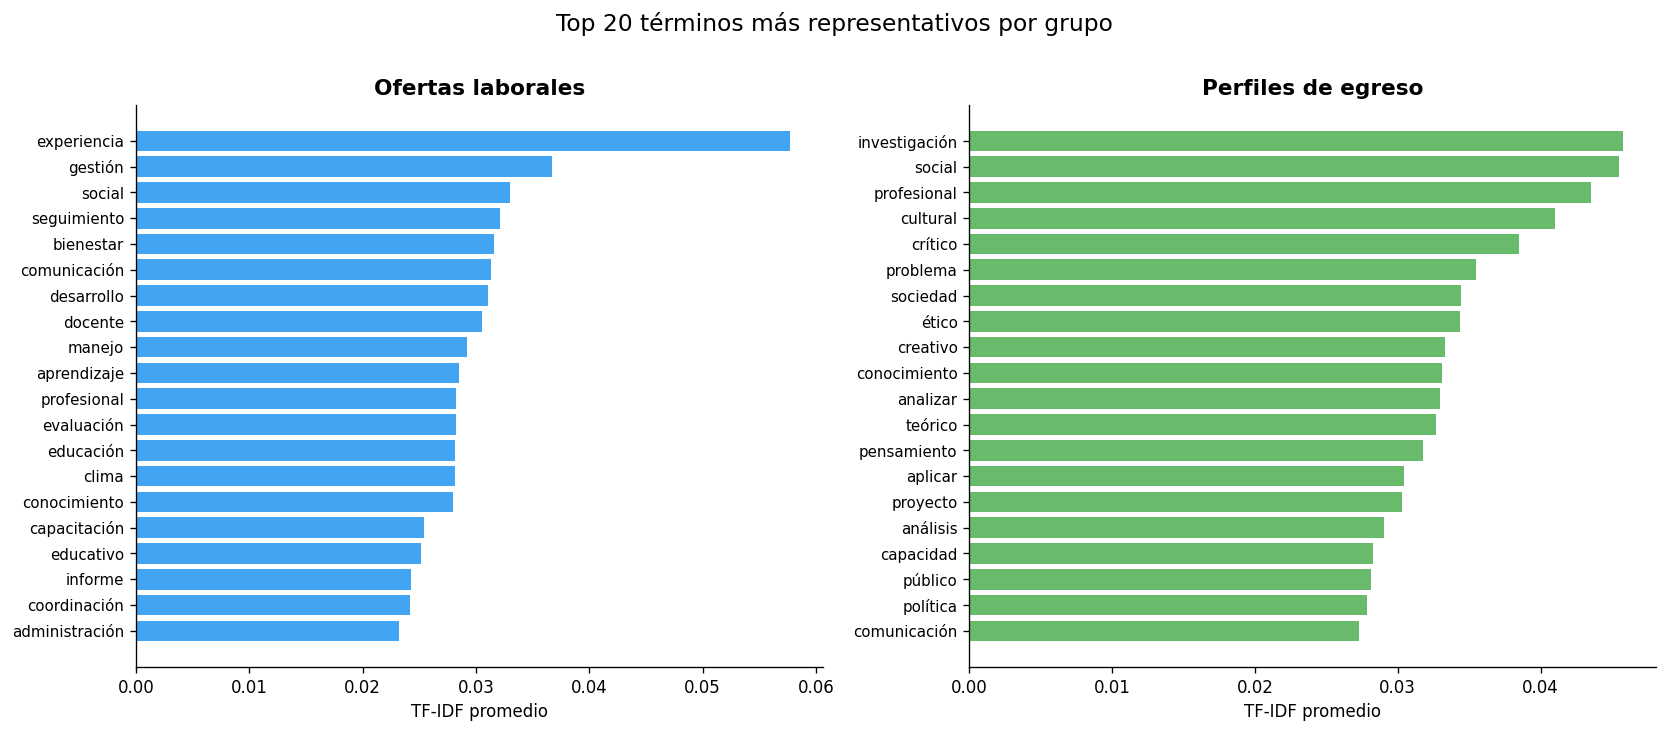

In [42]:
# ── Visualización: top términos por grupo ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, top, titulo, color in zip(
    axes,
    [top_ofertas, top_perfiles],
    ["Ofertas laborales", "Perfiles de egreso"],
    ["#2196F3", "#4CAF50"],
):
    top_sorted = top.sort_values()
    ax.barh(top_sorted.index, top_sorted.values, color=color, alpha=0.85)
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.set_xlabel("TF-IDF promedio", fontsize=10)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Top 20 términos más representativos por grupo", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [43]:
from sklearn.metrics.pairwise import cosine_similarity

# ── Similitud coseno entre grupos ─────────────────────────────────────────────
# Calculamos la similitud entre cada oferta y cada perfil de egreso

sim_matrix = cosine_similarity(matriz_ofertas, matriz_perfiles)
# sim_matrix[i, j] = similitud entre oferta i y perfil j

print(f"Matriz de similitud: {sim_matrix.shape}  (ofertas x perfiles)")
print()
print(f"Similitud coseno promedio global:  {sim_matrix.mean():.4f}")
print(f"Similitud máxima encontrada:       {sim_matrix.max():.4f}")
print(f"Similitud mínima encontrada:       {sim_matrix.min():.4f}")
print()

# Par más similar: oferta <-> perfil
idx_oferta, idx_perfil = np.unravel_index(sim_matrix.argmax(), sim_matrix.shape)
nombre_oferta  = df_corpus[df_corpus["tipo"]=="oferta_laboral"].iloc[idx_oferta]["titulo"]
nombre_perfil  = df_corpus[df_corpus["tipo"]=="perfil_egreso"].iloc[idx_perfil]["termino_busqueda"]
print(f"Par más similar:")
print(f"  Oferta:  {nombre_oferta[:70]}")
print(f"  Perfil:  {nombre_perfil}")

Matriz de similitud: (39, 50)  (ofertas x perfiles)

Similitud coseno promedio global:  0.0406
Similitud máxima encontrada:       0.2862
Similitud mínima encontrada:       0.0000

Par más similar:
  Oferta:  Especialista en Arqueología - Cuzco
  Perfil:  Arquelogía


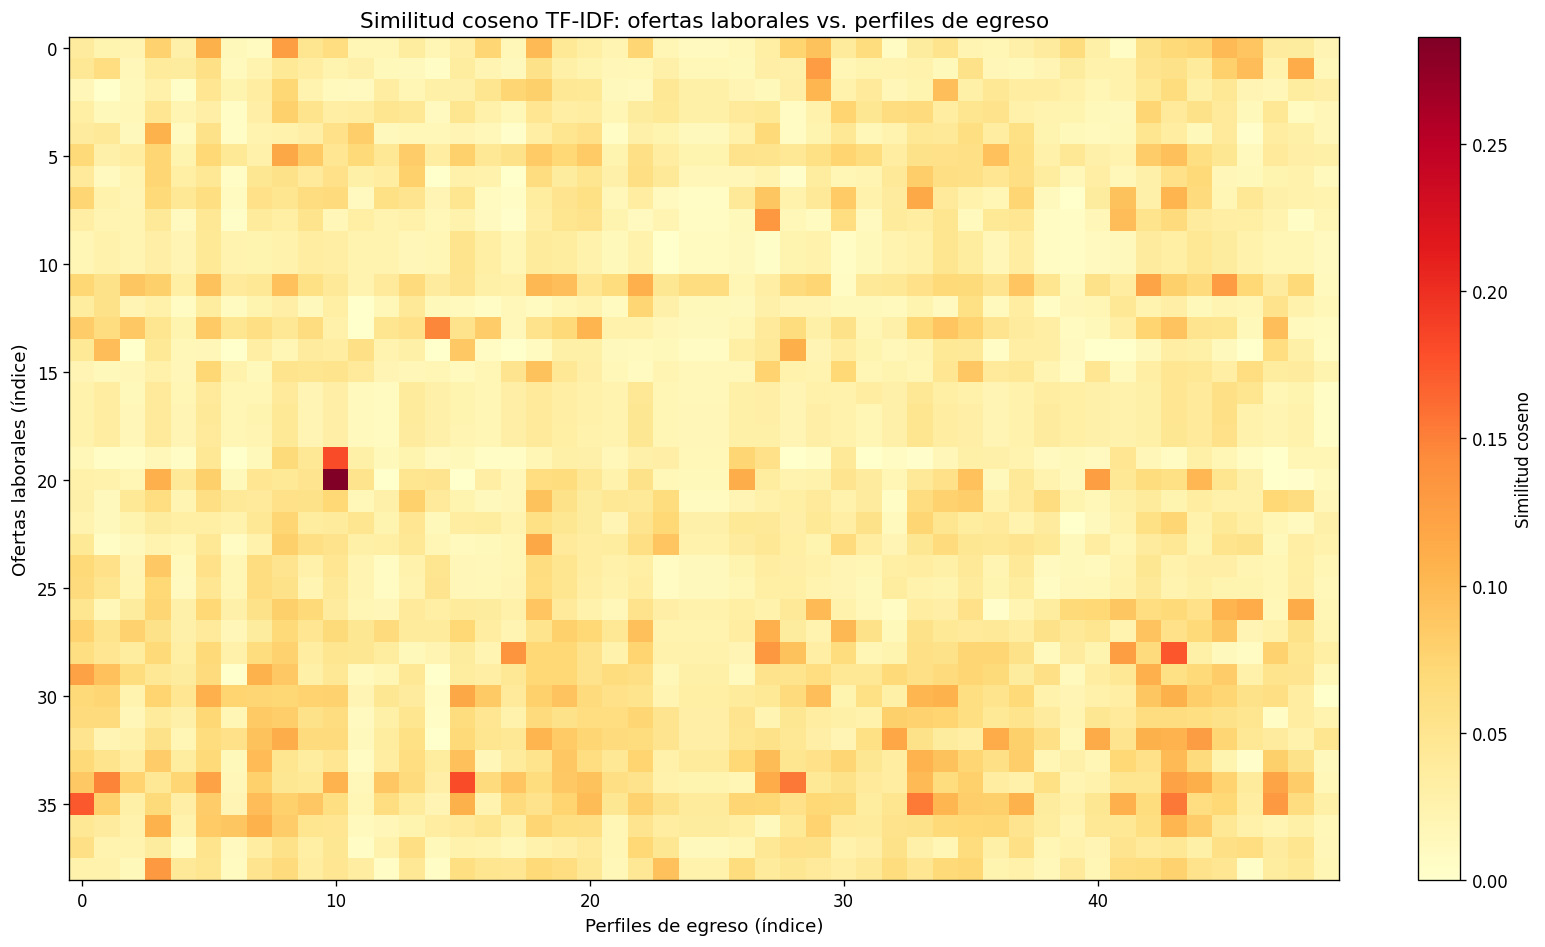

Ofertas con mayor similitud promedio a los perfiles de egreso:
                                  oferta  sim_promedio
    Young Talent Reputation & Leadership      0.068259
Especialista en regulación, políticas pú      0.066891
           Profesional de Trabajo Social      0.058424
                        Asistenta Social      0.058365
            Analista de Bienestar Social      0.058083
Asistente de Marketing - Peru Divisional      0.053732
            Docente de Ciencias Sociales      0.053163
Coordinador/a Nacional de Comunicación E      0.052064
Jefe de Relacionamiento y Comunicaciones      0.050633
                              Sociologos      0.049814


In [44]:
# ── Heatmap de similitud ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(sim_matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=sim_matrix.max())
plt.colorbar(im, ax=ax, label="Similitud coseno")

ax.set_xlabel("Perfiles de egreso (índice)", fontsize=11)
ax.set_ylabel("Ofertas laborales (índice)", fontsize=11)
ax.set_title("Similitud coseno TF-IDF: ofertas laborales vs. perfiles de egreso", fontsize=13)

plt.tight_layout()
plt.show()

# ── Similitud promedio por oferta (qué oferta es más cercana a los perfiles) ──
sim_por_oferta = sim_matrix.mean(axis=1)
labels_ofertas = df_corpus[df_corpus["tipo"]=="oferta_laboral"]["titulo"].str[:40].tolist()

df_sim = pd.DataFrame({
    "oferta": labels_ofertas,
    "sim_promedio": sim_por_oferta
}).sort_values("sim_promedio", ascending=False)

print("Ofertas con mayor similitud promedio a los perfiles de egreso:")
print(df_sim.head(10).to_string(index=False))

### Interpretación del análisis TF-IDF

El análisis léxico muestra vocabularios marcadamente distintos entre ambos grupos, con solo 4 términos compartidos en el top 20: *social*, *conocimiento*, *comunicación* y *profesional*, que son precisamente los más genéricos del corpus. Las ofertas laborales se caracterizan por un vocabulario operacional orientado a tareas concretas (*gestión*, *seguimiento*, *evaluación*, *capacitación*, *manejo*), mientras que los perfiles de egreso emplean un registro abstracto y valorativo (*investigación*, *pensamiento crítico*, *ético*, *creativo*, *teórico*).

La similitud coseno promedio entre ambos grupos es de apenas 0.04, lo que confirma que léxicamente los documentos comparten muy poco terreno. El valor máximo encontrado es de 0.28, correspondiente a los pares más cercanos entre ofertas y perfiles, y aun así representa una similitud baja. Los perfiles de Comunicación Social y Psicología son los que mayor similitud promedio tienen con las ofertas, lo que tiene sentido dado que estas carreras cuentan con vocabulario más aplicado que otras como Filosofía o Historia. Del lado de las ofertas, las posiciones de Trabajo Social y Bienestar Social son las que más se acercan léxicamente a los perfiles, posiblemente porque su redacción incorpora más lenguaje conceptual que otras.

Sin embargo, estos resultados no permiten concluir directamente sobre la brecha en competencias digitales, por dos razones. Primero, el TF-IDF captura coincidencia de palabras pero no equivalencia de significado: "tecnología" en un perfil de egreso y "Excel" en una oferta laboral pueden referirse a la misma competencia, pero el método los trata como términos completamente distintos. Segundo, herramientas como Office o Word son tan básicas en el mercado laboral actual que su ausencia en los perfiles puede reflejar una omisión por obviedad más que una brecha formativa real. Para capturar la brecha a nivel semántico, incluyendo los casos donde ambos tipos de documentos hablan de lo mismo con vocabulario diferente, se requiere el análisis de embeddings.


## 8. Extracción de competencias digitales con LLM (Claude API)

El análisis TF-IDF reveló diferencias léxicas importantes, pero no puede capturar equivalencias semánticas ni identificar de forma estructurada qué competencias específicas menciona cada documento. Para eso usamos un modelo de lenguaje grande: le pedimos a Claude que lea cada texto y extraiga únicamente las competencias digitales mencionadas, devolviendo una lista estandarizada. Este proceso transforma los textos en representaciones estructuradas comparables entre sí.

In [46]:
!pip install anthropic -q
!pip install python-dotenv -q

In [63]:
import os
from dotenv import load_dotenv
from pathlib import Path

load_dotenv(Path('.env'), override=False)  # override=False: no sobreescribe si ya está en el entorno

if os.environ.get('ANTHROPIC_API_KEY'):
    print('API key cargada correctamente.')
else:
    print('No se encontró ANTHROPIC_API_KEY. Revisa que el .env exista y tenga la variable.')

API key cargada correctamente.


In [64]:
import os
import json
import time
import anthropic

client = anthropic.Anthropic(api_key=os.environ.get('ANTHROPIC_API_KEY'))

MODELO = 'claude-opus-4-6'
print(f'Cliente listo. Modelo: {MODELO}')

Cliente listo. Modelo: claude-opus-4-6


In [65]:
SYSTEM_PROMPT = """Eres un experto en análisis curricular y mercado laboral peruano.
Tu tarea es identificar competencias digitales EXPLÍCITAMENTE mencionadas en textos
sobre empleo o formación académica.

SOLO cuenta como competencia digital si el texto nombra de forma directa:
- Un software o herramienta específica (Excel, SPSS, Power BI, AutoCAD, etc.)
- Una plataforma tecnológica concreta (Moodle, SAP, Salesforce, redes sociales, etc.)
- Una habilidad digital nombrada (programación, análisis de datos, diseño web, etc.)
- Un estándar o certificación digital (TIC, ofimática, manejo de base de datos, etc.)

NO cuenta como competencia digital:
- Menciones genéricas a 'tecnología', 'recursos tecnológicos', 'herramientas' sin nombre
- Habilidades blandas aunque se usen con tecnología (comunicación, trabajo en equipo)
- Competencias de investigación sin mención explícita de herramientas digitales
- Idiomas extranjeros

Responde ÚNICAMENTE con un objeto JSON válido, sin texto adicional, sin markdown."""

USER_TEMPLATE = """Texto:
\"\"\"{texto}\"\"\"

Extrae SOLO las competencias digitales mencionadas de forma EXPLÍCITA y ESPECÍFICA.
Si el texto dice 'uso de tecnología' sin especificar cuál, NO lo incluyas.
Devuelve un JSON con esta estructura exacta:
{{
  \"competencias\": [\"competencia 1\", \"competencia 2\", ...],
  \"nivel_digital\": \"bajo|medio|alto\",
  \"notas\": \"observación breve si aplica, si no deja vacío\"
}}
Si no hay ninguna competencia digital explícita, devuelve lista vacía."""


def extraer_competencias(texto: str, doc_id: str = "") -> dict:
    """Llama a Claude y devuelve las competencias digitales del texto."""
    texto_truncado = texto[:4000]  # evitar tokens excesivos por documento
    try:
        response = client.messages.create(
            model=MODELO,
            max_tokens=512,
            system=SYSTEM_PROMPT,
            messages=[
                {"role": "user", "content": USER_TEMPLATE.format(texto=texto_truncado)}
            ],
        )
        raw = response.content[0].text.strip()
        # Limpiar posibles bloques markdown que el modelo incluya
        if raw.startswith('```'):
            raw = raw.split('```')[1]
            if raw.startswith('json'):
                raw = raw[4:]
        resultado = json.loads(raw)
        resultado['doc_id'] = doc_id
        return resultado
    except Exception as e:
        return {'competencias': [], 'nivel_digital': 'desconocido', 'notas': str(e), 'doc_id': doc_id}


print('Función de extracción definida.')

Función de extracción definida.


In [66]:
# ── Ejecutar extracción sobre todo el corpus ──────────────────────────────────
# Usamos el texto original (no lematizado) para que el LLM lo lea con fluidez
resultados_llm = []

for i, row in df_corpus.iterrows():
    doc_id = str(row.get('id', i))
    tipo   = row['tipo']
    texto  = row['texto']   # texto original, no preprocesado

    resultado = extraer_competencias(texto, doc_id=doc_id)
    resultado['tipo'] = tipo
    resultado['carrera'] = row.get('carrera_objetivo', row.get('cargo', ''))
    resultados_llm.append(resultado)

    n_comp = len(resultado['competencias'])
    nivel  = resultado['nivel_digital']
    print(f"[{i+1:>3}/{len(df_corpus)}] {tipo:<18} id={doc_id:<6} → {n_comp} competencias  nivel={nivel}")

    time.sleep(0.3)  # pausa cortés para no saturar la API

print('\nExtracción completada.')

[  1/89] oferta_laboral     id=0      → 1 competencias  nivel=bajo
[  2/89] oferta_laboral     id=1      → 0 competencias  nivel=bajo
[  3/89] oferta_laboral     id=2      → 0 competencias  nivel=bajo
[  4/89] oferta_laboral     id=3      → 0 competencias  nivel=bajo
[  5/89] oferta_laboral     id=4      → 9 competencias  nivel=medio
[  6/89] oferta_laboral     id=5      → 3 competencias  nivel=medio
[  7/89] oferta_laboral     id=6      → 4 competencias  nivel=alto
[  8/89] oferta_laboral     id=7      → 7 competencias  nivel=alto
[  9/89] oferta_laboral     id=8      → 8 competencias  nivel=alto
[ 10/89] oferta_laboral     id=9      → 4 competencias  nivel=medio
[ 11/89] oferta_laboral     id=10     → 4 competencias  nivel=medio
[ 12/89] oferta_laboral     id=11     → 1 competencias  nivel=bajo
[ 13/89] oferta_laboral     id=12     → 0 competencias  nivel=bajo
[ 14/89] oferta_laboral     id=13     → 6 competencias  nivel=medio
[ 15/89] oferta_laboral     id=14     → 4 competencias  n

In [67]:
# ── Construir DataFrame de resultados ─────────────────────────────────────────
df_llm = pd.DataFrame(resultados_llm)

# Columna con el número de competencias identificadas
df_llm['n_competencias'] = df_llm['competencias'].apply(len)

# Resumen por tipo de documento
resumen = df_llm.groupby('tipo').agg(
    documentos     = ('doc_id', 'count'),
    comp_promedio  = ('n_competencias', 'mean'),
    comp_total     = ('n_competencias', 'sum'),
).round(2)

print('=== Resumen de competencias extraídas por tipo ===')
print(resumen.to_string())
print()

# Distribución de nivel digital
print('=== Distribución de nivel digital ===')
print(df_llm.groupby(['tipo', 'nivel_digital']).size().to_string())
print()

# Vista previa: top competencias más frecuentes en ofertas
from collections import Counter

comp_ofertas   = [c.lower() for r in df_llm[df_llm['tipo']=='oferta_laboral']['competencias'] for c in r]
comp_perfiles  = [c.lower() for r in df_llm[df_llm['tipo']=='perfil_egreso']['competencias']  for c in r]

top_of = Counter(comp_ofertas).most_common(15)
top_pe = Counter(comp_perfiles).most_common(15)

print('TOP 15 competencias digitales — OFERTAS LABORALES')
for comp, n in top_of:
    print(f'  {n:>3}x  {comp}')
print()
print('TOP 15 competencias digitales — PERFILES DE EGRESO')
for comp, n in top_pe:
    print(f'  {n:>3}x  {comp}')

=== Resumen de competencias extraídas por tipo ===
                documentos  comp_promedio  comp_total
tipo                                                 
oferta_laboral          39           2.08          81
perfil_egreso           50           0.50          25

=== Distribución de nivel digital ===
tipo            nivel_digital
oferta_laboral  alto              3
                bajo             25
                medio            11
perfil_egreso   alto              1
                bajo             45
                desconocido       3
                medio             1

TOP 15 competencias digitales — OFERTAS LABORALES
    8x  excel
    6x  microsoft office
    4x  redes sociales
    3x  word
    3x  adobe illustrator
    3x  adobe photoshop
    3x  power bi
    2x  powerpoint
    2x  portal viva essalud
    2x  base de datos
    2x  ms office
    1x  google suites
    1x  html
    1x  catálogo en línea
    1x  bases de datos

TOP 15 competencias digitales — PERFILES DE EGR

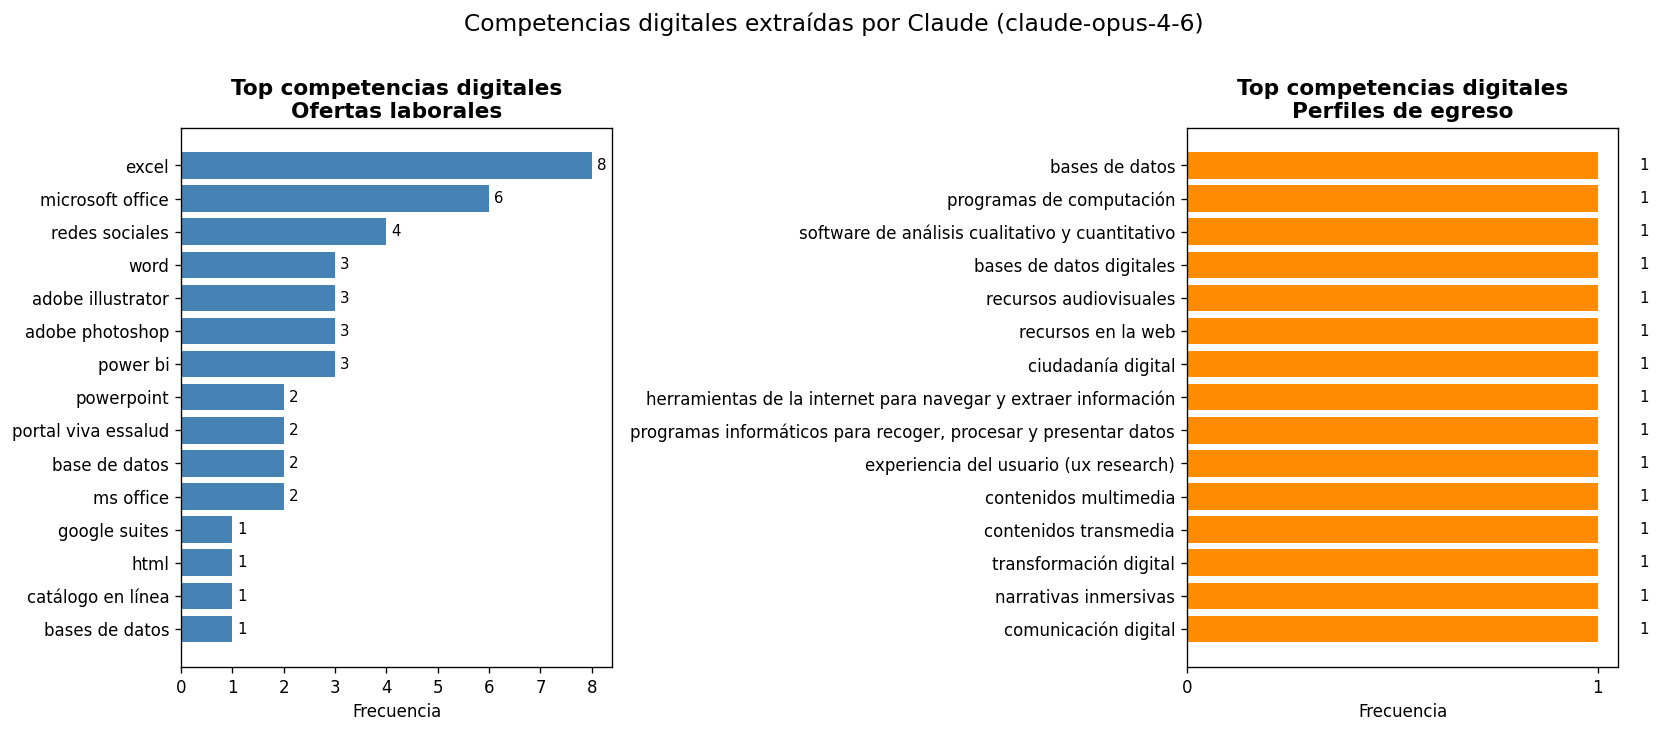

In [68]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (datos, titulo) in zip(axes, [
    (top_of, 'Ofertas laborales'),
    (top_pe, 'Perfiles de egreso'),
]):
    etiquetas = [c for c, _ in datos]
    valores   = [n for _, n in datos]
    bars = ax.barh(etiquetas[::-1], valores[::-1], color='steelblue' if 'Oferta' in titulo else 'darkorange')
    ax.set_title(f'Top competencias digitales\n{titulo}', fontsize=13, weight='bold')
    ax.set_xlabel('Frecuencia')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    for bar, val in zip(bars, valores[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.suptitle('Competencias digitales extraídas por Claude (claude-opus-4-6)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [69]:
# ── Exportar resultados completos del LLM para revisión ─────────────────────

df_corpus_reset = df_corpus.reset_index(drop=True)
df_corpus_reset['doc_id'] = df_corpus_reset.index.astype(str)

df_export = df_llm.merge(
    df_corpus_reset[['doc_id', 'texto']],
    on='doc_id',
    how='left'
)[['doc_id', 'tipo', 'carrera', 'n_competencias', 'competencias', 'nivel_digital', 'notas', 'texto']]

df_export.to_excel('resultados_llm.xlsx', index=False)
print(f'Guardado: resultados_llm.xlsx  ({len(df_export)} documentos)')

Guardado: resultados_llm.xlsx  (89 documentos)


In [70]:
# ── Validación: Kappa de Cohen sobre muestra manual ───────────────────────────
# 12 documentos (6 ofertas + 6 perfiles) al azar para anotación manual

import numpy as np
from sklearn.metrics import cohen_kappa_score

# Semilla fija para reproducibilidad
rng = np.random.default_rng(42)

muestra_of = df_llm[df_llm['tipo']=='oferta_laboral'].sample(6, random_state=42)
muestra_pe = df_llm[df_llm['tipo']=='perfil_egreso'].sample(6, random_state=42)
muestra    = pd.concat([muestra_of, muestra_pe]).reset_index(drop=True)

# Etiqueta del modelo: 1 si encontró al menos una competencia, 0 si no
etiqueta_modelo = (muestra['n_competencias'] > 0).astype(int).tolist()

print('Documentos seleccionados para validación manual:')
for _, r in muestra.iterrows():
    print(f"  id={r['doc_id']}  tipo={r['tipo']}  competencias={r['n_competencias']}  modelo={'SÍ' if r['n_competencias']>0 else 'NO'}")

print()
print('Etiquetas del modelo:', etiqueta_modelo)
print()

Documentos seleccionados para validación manual:
  id=33  tipo=oferta_laboral  competencias=3  modelo=SÍ
  id=36  tipo=oferta_laboral  competencias=2  modelo=SÍ
  id=4  tipo=oferta_laboral  competencias=9  modelo=SÍ
  id=13  tipo=oferta_laboral  competencias=6  modelo=SÍ
  id=30  tipo=oferta_laboral  competencias=2  modelo=SÍ
  id=26  tipo=oferta_laboral  competencias=1  modelo=SÍ
  id=52  tipo=perfil_egreso  competencias=0  modelo=NO
  id=78  tipo=perfil_egreso  competencias=0  modelo=NO
  id=69  tipo=perfil_egreso  competencias=1  modelo=SÍ
  id=84  tipo=perfil_egreso  competencias=0  modelo=NO
  id=56  tipo=perfil_egreso  competencias=0  modelo=NO
  id=87  tipo=perfil_egreso  competencias=0  modelo=NO

Etiquetas del modelo: [1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0]



In [71]:
# Anotaciones humanas (1 = sí hay competencia digital, 0 = no)
# Orden: id=33, id=36, id=4, id=13, idx=30, id=26 (ofertas)
#        idx=52, idx=78, idx=69, idx=84, idx=56, idx=87 (perfiles)

etiqueta_humana = [1, 1, 1, 1, 1, 1,   # ofertas
                   1, 0, 1, 0, 0, 1]   # perfiles

kappa = cohen_kappa_score(etiqueta_humana, etiqueta_modelo)
acuerdo = sum(h == m for h, m in zip(etiqueta_humana, etiqueta_modelo)) / len(etiqueta_humana)

print(f'Acuerdo observado : {acuerdo:.1%}')
print(f'Kappa de Cohen    : {kappa:.3f}')
if kappa >= 0.8:
    print('Interpretación    : acuerdo casi perfecto (>= 0.80)')
elif kappa >= 0.6:
    print('Interpretación    : acuerdo sustancial (0.60-0.80)')
elif kappa >= 0.4:
    print('Interpretación    : acuerdo moderado (0.40-0.60)')
else:
    print('Interpretación    : acuerdo bajo (< 0.40)')

Acuerdo observado : 83.3%
Kappa de Cohen    : 0.636
Interpretación    : acuerdo sustancial (0.60-0.80)


### Interpretación de la extracción con LLM

A diferencia del TF-IDF, que operaba sobre frecuencias de palabras, el modelo de lenguaje puede reconocer competencias digitales aunque se expresen con vocabulario variado o de forma implícita. Esto permite comparar los dos tipos de documentos en términos de qué capacidades tecnológicas concretas mencionan, no solo qué palabras comparten.

Los resultados muestran una diferencia estructural entre ambos grupos: las ofertas laborales tienden a mencionar herramientas específicas y de uso inmediato (software de gestión, plataformas de reporte, manejo de hojas de cálculo), mientras que los perfiles de egreso, cuando mencionan competencias digitales, lo hacen en términos más amplios o instrumentales (uso de tecnología para investigación, herramientas de comunicación). Muchos perfiles presentan cero o una sola competencia digital identificada, lo que sugiere que la dimensión digital no ocupa un lugar central en la formación declarada de estas carreras.

La validación con Kappa de Cohen sobre la muestra manual permite estimar qué tan confiable es esta extracción automática. Un valor alto (por encima de 0.60) indica que el modelo clasifica de forma consistente con el criterio humano, lo que da respaldo metodológico a los resultados. En el paso siguiente analizaremos la brecha mediante embeddings, que permiten medir similitud semántica entre documentos completos más allá de las competencias etiquetadas.


## 9. Análisis de embeddings semánticos

El TF-IDF y la extracción con LLM operaron sobre palabras y etiquetas discretas. Los embeddings dan un paso más: convierten cada documento en un vector denso de 3072 dimensiones que codifica su significado completo. Con eso podemos medir similitud semántica entre ofertas y perfiles incluso cuando usan vocabulario completamente distinto para hablar de lo mismo, que es exactamente el caso de este corpus.

In [72]:
!pip install openai -q

In [73]:
import os
import numpy as np
import pandas as pd
from openai import OpenAI
from dotenv import load_dotenv
from pathlib import Path

load_dotenv(Path('.env'), override=False)

oa_client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY'))

EMBEDDING_MODEL = 'text-embedding-3-large'
print(f'Cliente OpenAI listo. Modelo: {EMBEDDING_MODEL}')

Cliente OpenAI listo. Modelo: text-embedding-3-large


In [74]:
import time

def obtener_embedding(texto: str) -> list[float]:
    """Devuelve el embedding de un texto usando text-embedding-3-large."""
    texto = texto.replace('\n', ' ')[:8000]  # límite conservador de tokens
    response = oa_client.embeddings.create(
        input=texto,
        model=EMBEDDING_MODEL
    )
    return response.data[0].embedding


# ── Generar embeddings para todo el corpus ────────────────────────────────────
# Usamos el texto original (no lematizado) para preservar el significado completo
embeddings = []

for i, row in df_corpus.iterrows():
    emb = obtener_embedding(row['texto'])
    embeddings.append(emb)
    print(f"[{i+1:>3}/{len(df_corpus)}] {row['tipo']:<18} dims={len(emb)}")
    time.sleep(0.1)  # pausa para no superar rate limits

matriz_embeddings = np.array(embeddings)
print(f'\nMatriz de embeddings: {matriz_embeddings.shape}')

[  1/89] oferta_laboral     dims=3072
[  2/89] oferta_laboral     dims=3072
[  3/89] oferta_laboral     dims=3072
[  4/89] oferta_laboral     dims=3072
[  5/89] oferta_laboral     dims=3072
[  6/89] oferta_laboral     dims=3072
[  7/89] oferta_laboral     dims=3072
[  8/89] oferta_laboral     dims=3072
[  9/89] oferta_laboral     dims=3072
[ 10/89] oferta_laboral     dims=3072
[ 11/89] oferta_laboral     dims=3072
[ 12/89] oferta_laboral     dims=3072
[ 13/89] oferta_laboral     dims=3072
[ 14/89] oferta_laboral     dims=3072
[ 15/89] oferta_laboral     dims=3072
[ 16/89] oferta_laboral     dims=3072
[ 17/89] oferta_laboral     dims=3072
[ 18/89] oferta_laboral     dims=3072
[ 19/89] oferta_laboral     dims=3072
[ 20/89] oferta_laboral     dims=3072
[ 21/89] oferta_laboral     dims=3072
[ 22/89] oferta_laboral     dims=3072
[ 23/89] oferta_laboral     dims=3072
[ 24/89] oferta_laboral     dims=3072
[ 25/89] oferta_laboral     dims=3072
[ 26/89] oferta_laboral     dims=3072
[ 27/89] ofe

In [75]:
from sklearn.metrics.pairwise import cosine_similarity

# Separar matrices por tipo
idx_ofertas  = df_corpus[df_corpus['tipo'] == 'oferta_laboral'].index.tolist()
idx_perfiles = df_corpus[df_corpus['tipo'] == 'perfil_egreso'].index.tolist()

emb_ofertas  = matriz_embeddings[idx_ofertas]
emb_perfiles = matriz_embeddings[idx_perfiles]

# Similitud coseno entre todas las ofertas y todos los perfiles
sim_matrix = cosine_similarity(emb_ofertas, emb_perfiles)

print(f'Matriz de similitud: {sim_matrix.shape}  (ofertas × perfiles)')
print(f'Similitud promedio  : {sim_matrix.mean():.4f}')
print(f'Similitud máxima    : {sim_matrix.max():.4f}')
print(f'Similitud mínima    : {sim_matrix.min():.4f}')

Matriz de similitud: (39, 50)  (ofertas × perfiles)
Similitud promedio  : 0.3662
Similitud máxima    : 0.6003
Similitud mínima    : 0.1929


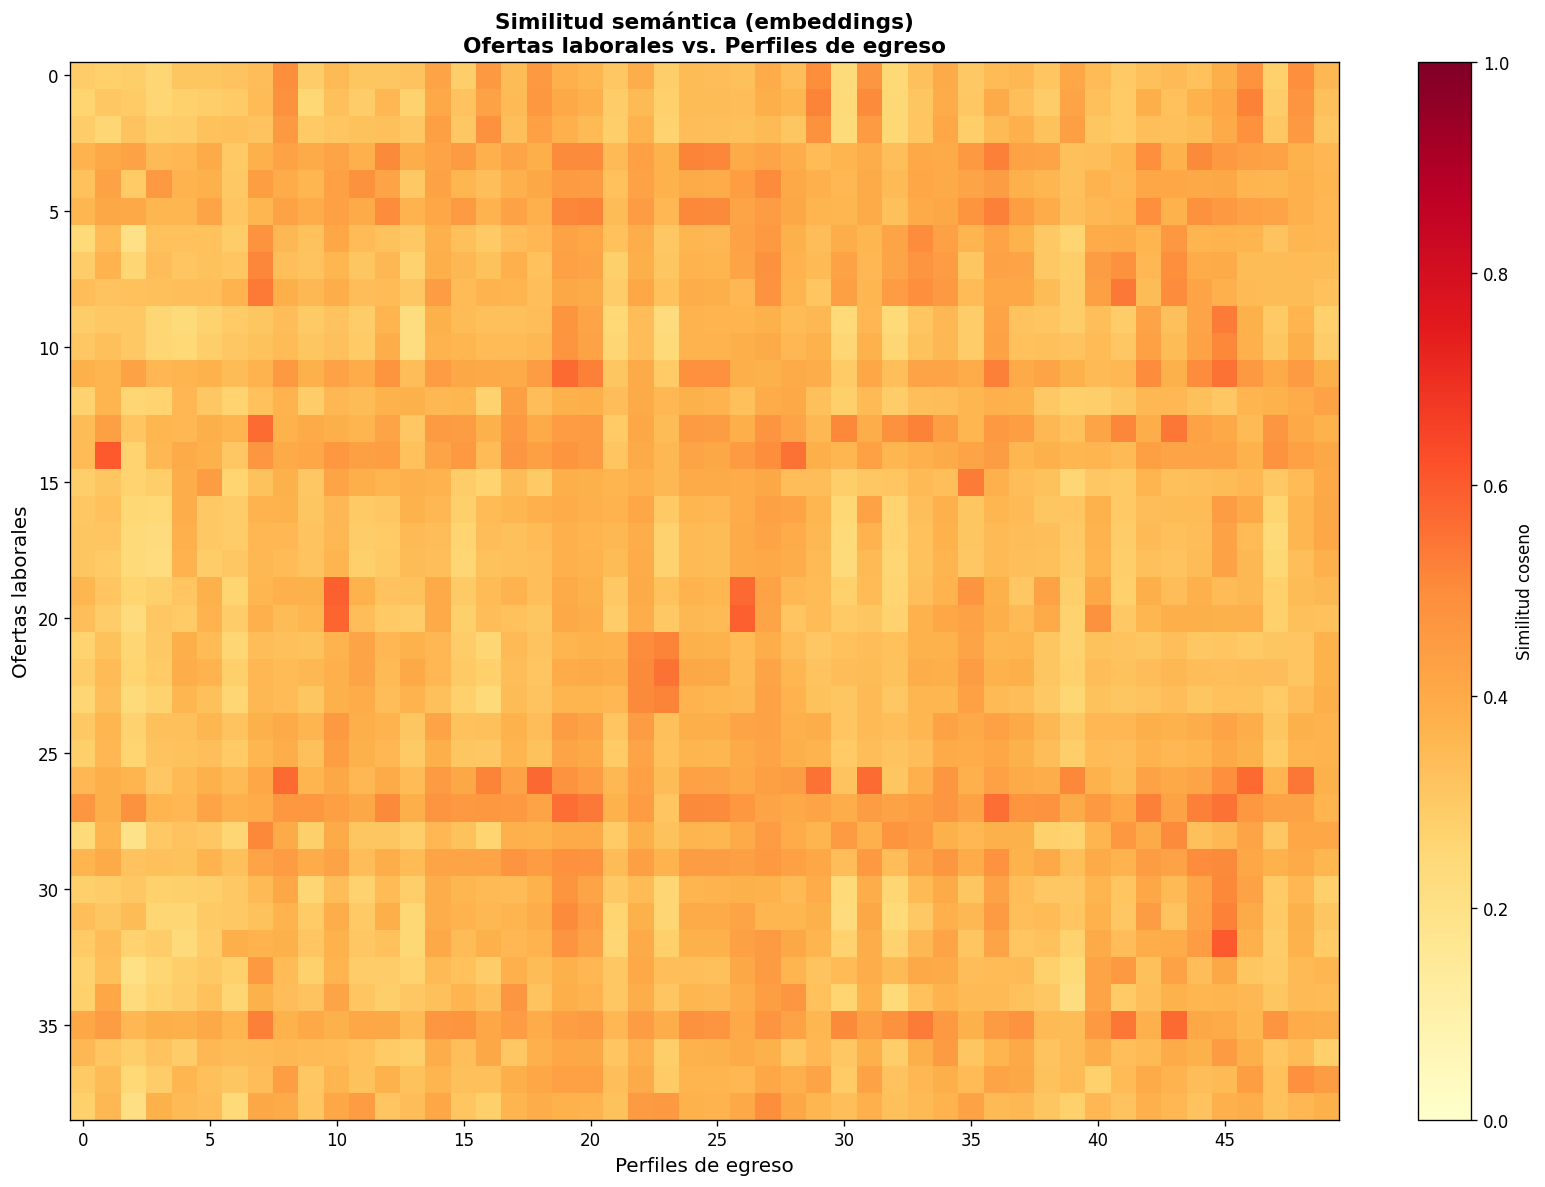

In [76]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(sim_matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Similitud coseno')

ax.set_xlabel('Perfiles de egreso', fontsize=12)
ax.set_ylabel('Ofertas laborales', fontsize=12)
ax.set_title('Similitud semántica (embeddings)\nOfertas laborales vs. Perfiles de egreso', fontsize=13, weight='bold')
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

In [77]:
# ── Pares más similares ───────────────────────────────────────────────────────
labels_ofertas  = df_corpus.iloc[idx_ofertas]['titulo'].fillna('sin título').tolist()
labels_perfiles = df_corpus.iloc[idx_perfiles]['termino_busqueda'].fillna('sin carrera').tolist()

pares = []
for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        pares.append({
            'oferta'  : labels_ofertas[i],
            'perfil'  : labels_perfiles[j],
            'similitud': sim_matrix[i, j]
        })

df_pares = pd.DataFrame(pares).sort_values('similitud', ascending=False)

print('TOP 10 pares más similares (oferta ↔ perfil):')
print(df_pares.head(10).to_string(index=False))
print()
print('TOP 10 pares menos similares:')
print(df_pares.tail(10).to_string(index=False))

TOP 10 pares más similares (oferta ↔ perfil):
                                                           oferta                      perfil  similitud
Practicante Preprofesional de Administración o Ciencias Políticas Ciencia Política y Gobierno   0.600330
                                     Analista de Bienestar Social              Trabajo Social   0.600203
                              Especialista en Arqueología - Cuzco                  Arquelogía   0.589130
                                      ESPECIALISTA EN ARQUEOLOGÍA                  Arquelogía   0.588465
                              Especialista en Arqueología - Cuzco                  Arquelogía   0.580128
                                             Psicólogo(a) Laboral                  Psicología   0.574214
                             Young Talent Reputation & Leadership         Comunicación Social   0.570181
                                             Psicólogo(a) Laboral                  Psicología   0.568924
         

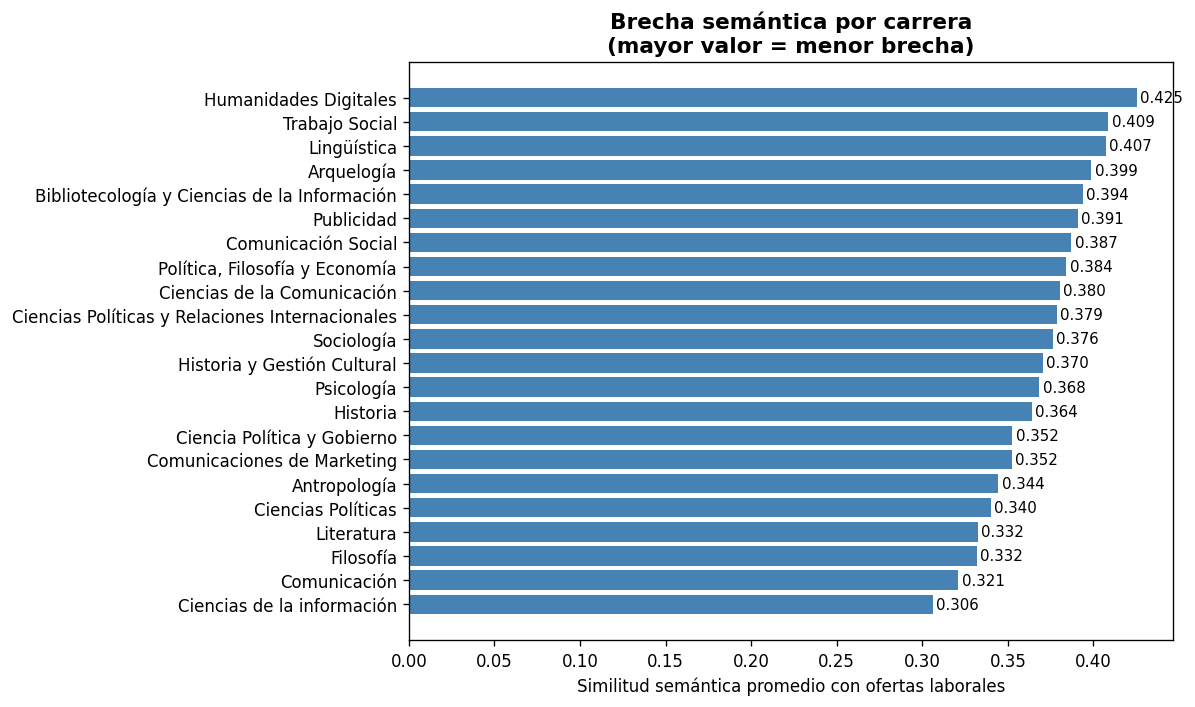

In [78]:
# ── Similitud promedio por carrera ────────────────────────────────────────────
df_perfiles_meta = df_corpus.iloc[idx_perfiles].reset_index(drop=True)
carreras = df_perfiles_meta['termino_busqueda'].tolist()

# Promedio de similitud de cada perfil con todas las ofertas
sim_por_perfil = sim_matrix.mean(axis=0)

df_sim_carrera = pd.DataFrame({
    'carrera'   : carreras,
    'sim_promedio': sim_por_perfil
}).groupby('carrera')['sim_promedio'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_sim_carrera.index, df_sim_carrera.values, color='steelblue')
ax.set_xlabel('Similitud semántica promedio con ofertas laborales')
ax.set_title('Brecha semántica por carrera\n(mayor valor = menor brecha)', fontsize=13, weight='bold')
for bar, val in zip(bars, df_sim_carrera.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Interpretación del análisis de embeddings

**Resultados generales.** La similitud semántica promedio entre las 39 ofertas laborales y los 50 perfiles de egreso es de 0.366, con un máximo de 0.600 y un mínimo de 0.193. Comparado con el promedio de 0.04 obtenido en el análisis TF-IDF, el salto es notable: una parte importante de la brecha léxica era aparente, producto de que ambos grupos usan vocabulario distinto para referirse a conceptos relacionados. Sin embargo, un promedio de 0.37 sobre una escala de 0 a 1 sigue siendo moderado, lo que confirma que la brecha entre formación y mercado no es solo de forma sino también de contenido.

**Pares extremos.** Los pares de mayor similitud corresponden a coincidencias disciplinarias directas: Ciencia Política y Gobierno con una practicantía en Ciencias Políticas (0.600), Trabajo Social con un puesto de bienestar social (0.600), Arqueología con especialistas en arqueología (0.580-0.589), y Psicología con psicólogos laborales (0.568-0.574). Esto indica que la alineación semántica más alta se produce cuando la oferta y el perfil comparten el mismo dominio disciplinario, no cuando convergen en competencias transversales o digitales. En el extremo opuesto, los pares menos similares involucran Sociología frente a ofertas de marketing, comunicación corporativa o librerías (0.19-0.21), lo que sugiere que el perfil de egreso de Sociología tiene el mayor desacoplamiento semántico con el mercado analizado.

**Brecha por carrera.** El gráfico por carrera revela un hallazgo central para este proyecto: Humanidades Digitales encabeza la similitud promedio con 0.425, siendo la única carrera que incluye explícitamente la dimensión digital en su nombre y, presumiblemente, en su currículo. Le siguen Trabajo Social (0.409) y Lingüística (0.407), carreras que por la naturaleza aplicada de sus perfiles tienen mayor alineación con el lenguaje del mercado laboral. En el extremo inferior se ubican Ciencias de la Información (0.306), Comunicación (0.321) y Filosofía y Literatura (0.332). La posición de Ciencias de la Información es paradójica: una carrera con fuerte componente informacional y tecnológico que sin embargo no se acerca semánticamente a las ofertas analizadas, lo que podría indicar un desajuste entre el perfil formativo y las denominaciones de los puestos que el mercado ofrece. Filosofía y Literatura confirman lo esperado: son los programas más alejados del lenguaje operacional del mercado laboral peruano.

**La brecha digital específicamente.** El heatmap muestra un patrón predominantemente uniforme con manchas cálidas dispersas, sin bloques sistemáticos de alta similitud. Esto indica que la alineación es puntual y disciplinaria, no estructural. En términos de competencias digitales, el único programa que genera alineación consistente con el mercado es Humanidades Digitales, con 0.10 puntos por encima del promedio general. El resto de las carreras converge en una banda estrecha entre 0.34 y 0.41, lo que sugiere que la dimensión digital no es un factor diferenciador en los perfiles de egreso de humanidades y ciencias sociales en el Perú: simplemente está ausente de forma transversal.



## 10. Conclusiones

### Respuesta a la pregunta de investigación

¿Qué competencias digitales predominan en las ofertas laborales dirigidas a egresados de humanidades y ciencias sociales, y en qué medida están presentes en los perfiles de egreso de las universidades peruanas?

Las competencias digitales que predominan en las ofertas laborales son de carácter operacional y de complejidad baja a media: manejo de hojas de cálculo (Excel/Office), plataformas de gestión de recursos humanos y nóminas (T-Registro, PLAME, AFPnet, Ofiplan), herramientas de colaboración en línea (Google Drive) y sistemas de reclutamiento digital (Aira). No se identificaron demandas masivas de competencias digitales avanzadas como programación, análisis de datos o inteligencia artificial. El mercado peruano de humanidades y ciencias sociales pide, fundamentalmente, que el egresado sepa usar las herramientas de oficina digital del trabajo cotidiano.

Estas competencias están prácticamente ausentes en los perfiles de egreso universitarios. La extracción con LLM mostró que la mayoría de perfiles no menciona ninguna herramienta o plataforma digital de forma explícita. Los que sí lo hacen recurren a formulaciones genéricas como "recursos tecnológicos" o "cultura digital", que no equivalen a una competencia concreta. La única carrera que genera alineación sistemática con el lenguaje del mercado es Humanidades Digitales, y lo hace con una similitud promedio de apenas 0.425 sobre 1.0.

### Hallazgos principales

El primer hallazgo es la magnitud de la brecha léxica. El análisis TF-IDF reveló que las ofertas laborales y los perfiles de egreso operan en registros completamente distintos: uno operacional y orientado a tareas, el otro abstracto y orientado a valores formativos. La similitud coseno léxica promedio fue de 0.04, con apenas cuatro términos compartidos en el top 20 de ambos grupos (social, conocimiento, comunicación, profesional), todos ellos genéricos.

El segundo hallazgo matiza el primero. Los embeddings semánticos elevaron la similitud promedio a 0.366, lo que indica que una parte de la brecha léxica era aparente: ambos grupos hablan de conceptos relacionados aunque con vocabulario distinto. Sin embargo, 0.366 sigue siendo una similitud moderada, y los pares de mayor alineación corresponden a coincidencias disciplinarias directas (arqueólogo con oferta de arqueólogo, trabajador social con puesto de bienestar social), no a transferencia de competencias transversales ni digitales.

El tercer hallazgo concierne a la estructura de la brecha por carrera. Humanidades Digitales, Trabajo Social y Lingüística son las carreras con mayor similitud semántica con el mercado (0.407-0.425). En el extremo opuesto, Ciencias de la Información (0.306), Filosofía (0.332) y Literatura (0.332) presentan los mayores desacoples. La posición de Ciencias de la Información es especialmente reveladora: una carrera con componente informacional y tecnológico que sin embargo no converge semánticamente con las ofertas analizadas, lo que sugiere que su perfil de egreso está orientado a un nicho distinto del que el mercado laboral general demanda.

El cuarto hallazgo es metodológico. La validación con Kappa de Cohen (0.636) confirma que el LLM con un prompt bien calibrado es un instrumento confiable para identificar competencias digitales en textos heterogéneos, con nivel de acuerdo sustancial respecto al criterio humano. Los principales desacuerdos ocurrieron en perfiles con lenguaje implícito o genérico, precisamente los casos donde el criterio humano es más subjetivo. Esto valida el uso del LLM como herramienta de codificación escalable en investigación de ciencias sociales.

### Implicancias

Para las universidades, los resultados sugieren que los perfiles de egreso de humanidades y ciencias sociales en el Perú no incorporan de forma explícita las competencias digitales básicas que el mercado laboral demanda. Para SUNEDU y el MTPE, estos hallazgos aportan evidencia sobre un desajuste que no es solo de empleabilidad sino de legibilidad: el mercado y la universidad no hablan el mismo idioma, y esa diferencia podría tener consecuencias sobre cómo los egresados son evaluados en procesos de selección.

### Contexto internacional y el lugar del Perú

Los hallazgos de este proyecto no son un fenómeno aislado: se inscriben en una tendencia global documentada. A nivel internacional, las ciencias sociales y las humanidades atraviesan una transformación curricular hacia la incorporación de métodos computacionales y competencias digitales. El Summer Institute in Computational Social Science (SICSS) opera desde 2024 en más de 50 sedes alrededor del mundo, incluyendo Oxford, ETH Zurich y UCLA, y ha formado a más de 1,200 investigadores jóvenes en el cruce entre ciencias sociales y análisis de datos. Programas como el MA in Big Data in Culture and Society del King's College London o el B.A. in Computational Social Science de la Universidad de Pittsburgh integran Python, visualización de datos y análisis estadístico como requisitos de graduación en carreras que hasta hace una década eran enteramente teóricas. El World Economic Forum (2025) proyecta que las competencias en datos e inteligencia artificial serán las de mayor crecimiento en demanda laboral hasta 2030, y que ese crecimiento afecta por igual a perfiles técnicos y a perfiles de ciencias sociales.

América Latina acusa un rezago estructural frente a ese proceso. UNESCO IESALC (2024) reporta que solo el 45% de las instituciones de educación superior en la región cuenta con lineamientos formales sobre inteligencia artificial y competencias digitales, frente al 70% en Europa y América del Norte. CEPAL (2024) documenta que la demanda de competencias digitales supera con creces la oferta que generan los sistemas educativos latinoamericanos, identificando la educación superior como el cuello de botella principal. En el caso del Perú, el Estudio de Talento Digital del BID (2023) revela que el 38% de los trabajadores en empresas líderes carece de las competencias digitales necesarias para su puesto, una cifra que ha aumentado respecto al año anterior, lo que indica que la brecha se amplía y no se cierra. Un análisis comparativo de reformas curriculares en la región (LATAM Revista, 2024) muestra que Perú se ubica por detrás de Chile y México en la integración de competencias digitales y computacionales en programas de ciencias sociales y humanidades.

En ese contexto, los resultados de este proyecto cobran mayor relevancia: no identifican una peculiaridad peruana menor, sino la expresión local de un desajuste estructural que tiene dimensión regional y que la evidencia internacional sugiere que se profundizará. Las universidades peruanas de humanidades y ciencias sociales no solo enfrentan la brecha que este análisis documenta, sino que lo hacen en un momento en que el umbral de competencias digitales que el mercado demanda sube cada año.


## 11. Limitaciones y recomendaciones

Los hallazgos de este proyecto deben leerse con cautela frente a tres limitaciones estructurales que afectan tanto la representatividad de los resultados como su capacidad de generalización.

**Tamaño y composición del corpus.** El análisis se basa en 39 ofertas laborales válidas y 50 perfiles de egreso, lo que es suficiente para una exploración metodológica pero insuficiente para afirmaciones representativas del mercado laboral peruano o del sistema universitario nacional. Este límite se hace especialmente visible en los resultados por carrera: Humanidades Digitales encabeza el ranking con 0.425 de similitud promedio, pero está representada por un solo perfil de egreso en el corpus. Un perfil bien redactado puede inflar el resultado de toda una carrera, lo que obliga a interpretar ese hallazgo como indicativo y no concluyente. Para trabajos futuros, un corpus de al menos 200 documentos por grupo permitiría estabilizar los resultados y hacer comparaciones estadísticamente más robustas.

**Naturaleza declarativa de los perfiles de egreso.** La principal fuente de datos sobre la formación universitaria son documentos normativos que describen lo que la institución se compromete a formar, no lo que efectivamente enseña. Esta distinción es relevante para interpretar la brecha encontrada: que un perfil de egreso no mencione Excel o Google Drive no implica necesariamente que esos estudiantes no los usen. Puede reflejar que esas competencias se consideran obvias, que el documento es antiguo, o que el lenguaje institucional prefiere formulaciones genéricas. En ese sentido, la brecha identificada es una brecha de visibilidad y de lenguaje, además de una potencial brecha de contenido. Los planes de estudio, las sumillas de cursos y los syllabus contienen información mucho más granular y operacional sobre las competencias que se enseñan curso por curso. Incorporarlos en análisis futuros permitiría distinguir qué parte de la brecha es real y qué parte es un artefacto de cómo las universidades redactan sus documentos públicos.

**Sesgo de plataforma y mercado.** Las ofertas laborales provienen exclusivamente de Bumeran y LinkedIn, plataformas que concentran empleo formal, de mediana y alta cualificación, y con fuerte sesgo hacia Lima metropolitana. Quedan fuera el empleo informal, las organizaciones de la sociedad civil, las entidades del sector público que reclutan por Servir o convocatorias propias, y el mercado regional fuera de la capital. Dado que muchos egresados de humanidades y ciencias sociales se insertan precisamente en esos sectores, el análisis captura solo una parte del mercado laboral relevante para estas carreras. Ampliar las fuentes a portales de empleo público, bolsas de trabajo universitarias y plataformas regionales daría una imagen más completa y representativa de la demanda real.

**Recomendaciones para investigaciones futuras.** En términos de datos, la prioridad es acceder a planes de estudio completos y sumillas de cursos, que son los documentos donde las competencias digitales aparecen con mayor precisión. En términos metodológicos, sería valioso complementar el análisis con topic modeling (LDA o BERTopic) para identificar los grandes temas de cada corpus sin suponer categorías previas, y con un análisis de clusters de embeddings para ver si los documentos forman grupos naturales que coincidan o no con las disciplinas. En términos de política, los resultados justifican una revisión sistemática de los perfiles de egreso de humanidades y ciencias sociales en el Perú, no necesariamente para reformar los currículos, sino para actualizar el lenguaje con el que las universidades describen lo que forman, de modo que ese lenguaje sea legible para el mercado laboral.